In [3]:
import pandas as pd

df_nsl = pd.read_csv("E:/Datasets/NSL-KDD/NSL-KDD.csv")

df_unsw = pd.read_csv("E:/Datasets/UNSWNB15/unsw.csv")

df_cicids = pd.read_csv("E:/Datasets/CICIDS2017/combined_file.csv")

df_cicids.columns = df_cicids.columns.str.replace(' ', '')

df_csecic = pd.read_csv("F:/Datasets/CSE-CIC-IDS2018/CSE-CIC-IDS2018.csv", low_memory=False)

df_ton = pd.read_csv("F:/Datasets/Ton_IoT/train_test_network.csv")

df_bot = pd.read_csv("F:/Datasets/Bot_IoT/Bot_IoT.csv", low_memory=False)

df_hikari = pd.read_csv("E:/Datasets/HIKARI2021/ALLFLOWMETER_HIKARI2021.csv")

df_unr = pd.read_csv("F:/Datasets/UNR-IDD/UNR-IDD.csv")

In [15]:
# === ATC Scorer (DataFrame, Final + Summaries) ===
# Dependencies: pandas. Place 'enterprise-attack.json' (and optionally 'ics-attack.json') in CWD.

from __future__ import annotations
import json, math, re, sys, os
from dataclasses import dataclass, field
from collections import defaultdict
from typing import Dict, List, Tuple, Any, Optional, Set
import pandas as pd

# -------------------------
# Data classes
# -------------------------
@dataclass
class EvidenceItem:
    tech_id: str
    ev_type: str            # 'label_map' | 'doc_claim' | 'artifact'
    strength: float = 1.0
    source: str = ""
    details: str = ""

@dataclass
class TechniqueInfo:
    tech_id: str
    name: str
    tactic_phase_names: List[str] = field(default_factory=list)
    data_text: str = ""
    weight: float = 1.0

@dataclass
class TacticInfo:
    key: str
    weight: float = 1.0

@dataclass
class ContextProfile:
    allowed_tactics: Set[str]
    observable_keywords: Set[str]
    tactic_weights: Dict[str, float]
    technique_weights: Dict[str, float]
    force_include_techniques: Set[str] = field(default_factory=set)
    force_exclude_techniques: Set[str] = field(default_factory=set)

@dataclass
class ScoringParams:
    ev_weights: Dict[str, float] = field(default_factory=lambda: {"artifact":0.9, "label_map":0.5, "doc_claim":0.4})
    tau_weak: float = 0.40
    tau_strong: float = 0.75
    alpha: float = 0.35  # breadth
    beta: float  = 0.50  # technique coverage
    gamma: float = 0.15  # evenness
    label_only_cap_q: float = 0.5  # cap q when only label evidence exists

@dataclass
class ATCReport:
    dataset: str
    ATC_score: float
    breadth: float
    technique_cov: float
    evenness: float
    num_in_scope_techniques: int
    num_evidenced_techniques: int
    tactic_summary: Dict[str, Dict[str, Any]]
    technique_details: Dict[str, Dict[str, Any]]

# -------------------------
# STIX loading (cached)
# -------------------------
_STIX_CACHE: Dict[Tuple[str,...], Tuple[Dict[str,TacticInfo], Dict[str,TechniqueInfo]]] = {}

def load_attack_stix(paths: List[str]) -> Tuple[Dict[str, TacticInfo], Dict[str, TechniqueInfo]]:
    key = tuple(sorted(paths))
    if key in _STIX_CACHE:
        return _STIX_CACHE[key]

    tactics: Dict[str, TacticInfo] = {}
    techniques: Dict[str, TechniqueInfo] = {}

    for p in paths:
        if not os.path.exists(p):
            print(f"[WARN] STIX file not found: {p}", file=sys.stderr)
            continue
        with open(p, "r", encoding="utf-8") as f:
            bundle = json.load(f)

        for obj in bundle.get("objects", []):
            if obj.get("type") == "attack-pattern":
                ext = next((r for r in obj.get("external_references", []) if r.get("source_name","").lower().startswith("mitre-attack")), None)
                tech_id = (ext or {}).get("external_id")
                if not tech_id:
                    continue
                phases = [kcp.get("phase_name","").strip().lower() for kcp in obj.get("kill_chain_phases", []) if kcp.get("phase_name")]
                data_text = " ".join([
                    obj.get("name",""),
                    obj.get("description",""),
                    obj.get("x_mitre_detection",""),
                    " ".join(obj.get("x_mitre_data_sources", [])) if isinstance(obj.get("x_mitre_data_sources"), list) else "",
                    str(obj.get("x_mitre_data_components",""))
                ])
                techniques[tech_id.upper()] = TechniqueInfo(
                    tech_id=tech_id.upper(),
                    name=obj.get("name", tech_id),
                    tactic_phase_names=phases,
                    data_text=(data_text or "")
                )
        for t in set(phase for tech in techniques.values() for phase in tech.tactic_phase_names):
            if t and t not in tactics:
                tactics[t] = TacticInfo(key=t, weight=1.0)

    _STIX_CACHE[key] = (tactics, techniques)
    return _STIX_CACHE[key]

# -------------------------
# Context profiles (generic) + dataset protocols
# -------------------------
BASE_ENTERPRISE_CONTEXT = ContextProfile(
    allowed_tactics=set("""
reconnaissance resource-development initial-access execution persistence privilege-escalation defense-evasion credential-access discovery lateral-movement collection command-and-control exfiltration impact
""".split()),
    observable_keywords=set("http https dns smtp imap pop3 smb ftp ssh rdp icmp tls ssl vpn proxy dhcp ntp snmp ospf".split()),
    tactic_weights={"lateral-movement":1.5, "command-and-control":1.5, "exfiltration":1.3},
    technique_weights={}
)

BASE_IOT_CONTEXT = ContextProfile(
    allowed_tactics=set("""
reconnaissance initial-access execution persistence discovery lateral-movement collection command-and-control exfiltration impact credential-access privilege-escalation defense-evasion
""".split()),
    observable_keywords=set("http https dns ntp mdns ssdp upnp mqtt coap amqp xmpp telnet ftp tftp ssh tcp udp icmp rtsp rtmp".split()),
    tactic_weights={"command-and-control":1.5, "exfiltration":1.2, "impact":1.2},
    technique_weights={}
)

BASE_ENCRYPTED_FLOW_CONTEXT = ContextProfile(
    allowed_tactics=set("""
reconnaissance resource-development impact command-and-control
""".split()),  # restrict to tactics observable via flow metadata
    observable_keywords=set("tcp udp tls ssl handshake syn ack icmp flow volume burst packet".split()),
    tactic_weights={"command-and-control":1.3, "impact":1.2, "reconnaissance":1.0},
    technique_weights={}
)


# SDN profile (for UNR-IDD)
BASE_SDN_CONTEXT = ContextProfile(
    allowed_tactics=set("""
reconnaissance resource-development initial-access execution persistence privilege-escalation defense-evasion credential-access discovery lateral-movement collection command-and-control exfiltration impact
""".split()),
    observable_keywords=set(
        "openflow flow_mod flow_removed packet_in packet_out barrier_stats group_mod meter_mod ovsdb ofpt "
        "onos opendaylight odl controller northbound southbound sdn_switch datapath dpctl ofctl "
        "grpc restconf netconf lldp stp arp icmp tcp udp".split()
    ),
    tactic_weights={"lateral-movement":1.5, "command-and-control":1.5, "exfiltration":1.3, "impact":1.2},
    technique_weights={}
)

# ICS-only tactics (added only when ics-attack.json is included)
ICS_TACTICS = {"inhibit-response-function", "impair-process-control"}

DATASET_DOMAIN = {
    "NSL-KDD": "enterprise",
    "UNSW-NB15": "enterprise",
    "CIC-IDS2017": "enterprise",
    "CSE-CIC-IDS2018": "enterprise",
    "BoT-IoT": "iot",
    "ToN-IoT": "iot",
    "UNR-IDD": "sdn",     # ← corrected
    "HIKARI-2021": "encrypted_flow",
}

DATASET_PROTOCOLS = {
    "NSL-KDD": ["tcp","udp","icmp"],
    "UNSW-NB15": ["tcp","udp","arp","sctp","gre","ipv6","igmp","rtp","ospf","l2tp","vrrp"],
    "CIC-IDS2017": ["dns","http","https","ntp","ssh","ftp","udp","smtps","tcp","smb","postgresql","bitcoin","rdp","snmp","rsync","ospf","mysql","pop3","pop3s","vnc","imaps","rtsp","telnet","smtp","imap","redis"],
    "CSE-CIC-IDS2018": ["tcp","udp"],
    "ToN-IoT": ["tcp","udp","icmp"],
    "BoT-IoT": ["udp","tcp","icmp","arp","ipv6-icmp"],
    "UNR-IDD": ["tcp","udp"],
    "HIKARI-2021": ["dns","https","http","snmp","udp","smb","smtps","ntp","telnet","ssh","redis","sip","rdp","tcp","rtsp","vnc","postgresql","mysql","smtp","ftp","pop3s","rsync","pop3","imaps","bitcoin","ospf","imap","sftp"]
}

EXTRA_OBSERVABLE_KEYWORDS = {
    "NSL-KDD": ["tcp","udp"],
    "UNSW-NB15": ["arp","sctp","gre","ipv6","igmp","rtp","l2tp","vrrp"],
    "CIC-IDS2017": ["smtps","postgresql","bitcoin","rsync","mysql","pop3s","vnc","imaps","rtsp","telnet","redis"],
    "CSE-CIC-IDS2018": [],
    "ToN-IoT": [],
    "BoT-IoT": ["arp","ipv6-icmp"],
    "UNR-IDD": ["openflow","flow_mod","packet_in","packet_out","ofpt","ovsdb","onos","opendaylight","controller"],  # ← SDN extras
    "HIKARI-2021": ["smb","smtps","redis","sip","rdp","vnc","postgresql","mysql","pop3s","rsync","pop3","imaps","bitcoin","ospf","imap","sftp","snmp"],
}

# -------------------------
# Dataset key normalization
# -------------------------
def _canon_name(name: str) -> str:
    return (name or "").replace("_", "-").strip()

def _resolve_key(d: dict, name: str) -> str:
    n = _canon_name(name).lower()
    for k in d.keys():
        if k.lower() == n:
            return k
    return name

# -------------------------
# Label → Technique maps (with exact vs contains cleanups)
# -------------------------
def label_to_regex_exact(label: str) -> re.Pattern:
    tokens = re.split(r'[^A-Za-z0-9]+', label.strip())
    tokens = [t for t in tokens if t]
    if not tokens:
        return re.compile(r"^$", re.IGNORECASE)
    pattern = r'^\s*' + r'[\s\-_]*'.join(re.escape(t) for t in tokens) + r'\s*$'
    return re.compile(pattern, re.IGNORECASE)

def label_to_regex_contains(label: str) -> re.Pattern:
    tokens = re.split(r'[^A-Za-z0-9]+', label.strip())
    tokens = [t for t in tokens if t]
    if not tokens:
        return re.compile(r"$^")  # never
    pattern = r'\b' + r'[\s\-_]*'.join(re.escape(t) for t in tokens) + r'\b'
    return re.compile(pattern, re.IGNORECASE)

def compile_label_map_mixed(exact_map: Dict[str, List[str]], contains_map: Dict[str, List[str]]) -> List[Tuple[re.Pattern, List[str]]]:
    compiled = []
    for lbl, tids in (exact_map or {}).items():
        compiled.append((label_to_regex_exact(lbl), [t.upper() for t in tids]))
    for lbl, tids in (contains_map or {}).items():
        compiled.append((label_to_regex_contains(lbl), [t.upper() for t in tids]))
    return compiled

# BASE exact maps (scanning→T1046 will be appended programmatically below)
DATASET_LABEL_MAPS_EXACT: Dict[str, Dict[str, List[str]]] = {
    "NSL-KDD": {
        "neptune": ["T1498.001"],
        "satan": ["T1595.002"],
        "ipsweep": ["T1595.001"],
        "smurf": ["T1498.001"],
        "portsweep": ["T1595.001"],
        "nmap": ["T1595.001"],
        "back": ["T1499.002"],
        "guess_passwd": ["T1110.001"],
        "mscan": ["T1595.002"],
        "warezmaster": ["T1105"],
        "teardrop": ["T1498.001"],
        "warezclient": ["T1105"],
        "apache2": ["T1498.003"],
        "processtable": ["T1499.001"],
        "snmpguess": ["T1110.001"],
        "saint": ["T1595.001"],
        "mailbomb": ["T1499.002"],
        "pod": ["T1498.001"],
        "snmpgetattack": ["T1046"],
        "httptunnel": ["T1572"],
        "buffer_overflow": ["T1068"],
        "land": ["T1498.001"],
        "multihop": ["T1090"],
        "rootkit": ["T1014"],
        "named": ["T1190"],
        "ps": ["T1057"],
        "sendmail": ["T1068"],
        "xterm": ["T1059"],
        "imap": ["T1110.001"],
        "loadmodule": ["T1059"],
        "ftp_write": ["T1105"],
        "xlock": ["T1110.001"],
        "phf": ["T1190"],
        "perl": ["T1059"],
        "xsnoop": ["T1040"],
        "spy": ["T1113"],
        "worm": ["T1210"],
        "sqlattack": ["T1190"],
        "udpstorm": ["T1498.002"],
    },
    "UNSW-NB15": {
        "generic": ["T1498.001"],
        "exploits": ["T1190"],
        "fuzzers": ["T1595.002"],
        "dos": ["T1498.001"],
        "reconnaissance": ["T1595.001"],
        "analysis": ["T1595.002"],
        "backdoor": ["T1547"],
        "shellcode": ["T1203"],
        "worms": ["T1210"],
    },
    "CIC-IDS2017": {
        "DoS Hulk": ["T1499.003"],
        "PortScan": ["T1595.001"],
        "DDoS": ["T1498.001"],
        "DoS Golden Eye": ["T1499.003"],
        "FTP-Patator": ["T1110.001"],
        "SSH-Patator": ["T1110.001"],
        "DoS slowloris": ["T1499.002"],
        "DoS Slowhttptest": ["T1499.001"],
        "Bot": ["T1071.001"],
        "Web Attack   Brute Force": ["T1110.001"],
        "Web Attack   XSS": ["T1190"],
        "Infiltration": ["T1190"],
        "Web Attack   Sql Injection": ["T1190"],
        "Heartbleed": ["T1190"],
    },
    "CSE-CIC-IDS2018": {
        "DDOS attack-HOIC": ["T1499.003"],
        "DoS attacks-LOIC-HTTP": ["T1499.003"],
        "DDoS attack-LOIC-UDP": ["T1498.001"],
        "DoS attacks-Hulk": ["T1499.003"],
        "DoS attacks-GoldenEye": ["T1499.003"],
        "DoS attacks-SlowHTTPTest": ["T1499.002"],
        "DoS attacks-Slowloris": ["T1499.002"],
        "Bot": ["T1071.001"],
        "FTP-BruteForce": ["T1110.001"],
        "SSH-Bruteforce": ["T1110.001"],
        "Infilteration": ["T1190"],
        "Brute Force -Web": ["T1110.001"],
        "Brute Force -XSS": ["T1190"],
        "SQL Injection": ["T1190"],
    },
    "BoT-IoT": {
        "DDoS": ["T1498.001"],
        "DoS": ["T1498.001"],
        "Reconnaissance": ["T1595.001"],
        "Theft": ["T1041"],
    },
    "ToN-IoT": {
        "scanning": ["T1595.001"],
        "ddos": ["T1498.001"],
        "injection": ["T1190"],
        "password": ["T1110.001"],
        "dos": ["T1499"],
        "backdoor": ["T1547"],     # we'll add T1105 below
        "ransomware": ["T1486"],
        "xss": ["T1190"],
        "mitm": ["T1557"],
    },
    "HIKARI-2021": {
        "Probing": ["T1595"],
        "Bruteforce": ["T1110.001"],
        "Bruteforce-XML": ["T1110.001"],
        "XMRIGCC CryptoMiner": ["T1496"],
    },
    "UNR-IDD": {
        "PortScan": ["T1595.001"],
        "TCP-SYN": ["T1498.001"],
        "Blackhole": ["T1498.001"],
        "Diversion": ["T1498.001"],
        "Overflow": ["T1499"],
    },
}

# Volatile labels → contains-style
DATASET_LABEL_MAPS_CONTAINS: Dict[str, Dict[str, List[str]]] = {
    "UNSW-NB15": {
        r"backdoors?": ["T1547"],
    },
    "ToN-IoT": {
        r"backdoors?": ["T1547","T1105"],  # persistence + ingress/tool transfer
    },
    "HIKARI-2021": {
        r"(xmrig(cc)?)|crypto\s*miner": ["T1496"],
    },
}

# Programmatic improvements:
def _append_unique(label_map: Dict[str, List[str]], key: str, tid: str):
    if key in label_map and tid not in label_map[key]:
        label_map[key].append(tid)

# Add T1046 alongside scanning/probing patterns
for ds, lm in DATASET_LABEL_MAPS_EXACT.items():
    for scan_key in ["PortScan","portsweep","ipsweep","nmap","satan","mscan","saint","reconnaissance","scanning","Probing","Reconnaissance","analysis","fuzzers"]:
        if scan_key in lm:
            _append_unique(lm, scan_key, "T1046")

# ToN-IoT backdoor → add T1105 (C2-adjacent)
DATASET_LABEL_MAPS_EXACT["ToN-IoT"]["backdoor"] = ["T1547","T1105"]

# Compile mixed maps (exact + contains)
DATASET_LABEL_MAPS_COMPILED: Dict[str, List[Tuple[re.Pattern, List[str]]]] = {
    ds: compile_label_map_mixed(DATASET_LABEL_MAPS_EXACT.get(ds, {}), DATASET_LABEL_MAPS_CONTAINS.get(ds, {}))
    for ds in set(list(DATASET_LABEL_MAPS_EXACT.keys()) + list(DATASET_LABEL_MAPS_CONTAINS.keys()))
}

# -------------------------
# Evidence from a DataFrame
# -------------------------
def evidence_from_df_labels(df: pd.DataFrame, label_col: str, compiled_map: List[Tuple[re.Pattern, List[str]]], source_name: str = "dataframe") -> List[EvidenceItem]:
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found. Columns: {list(df.columns)}")
    ev: List[EvidenceItem] = []
    for lab in df[label_col].astype(str).fillna(""):
        txt = lab.strip()
        if not txt:
            continue
        for rex, tids in compiled_map:
            if rex.search(txt):
                for tid in tids:
                    ev.append(EvidenceItem(tech_id=tid.upper(), ev_type="label_map", strength=1.0, source=source_name, details=f"label='{txt}'"))
                break  # stop at first match
    return ev

# -------------------------
# Scoping + context builders
# -------------------------
def build_context_for_dataset(dataset: str, stix_paths: List[str], extra_observable_keywords: Optional[List[str]] = None) -> ContextProfile:
    dom_key = _resolve_key(DATASET_DOMAIN, dataset)
    domain = DATASET_DOMAIN.get(dom_key, DATASET_DOMAIN.get(dataset))
    if domain == "enterprise":
        base = BASE_ENTERPRISE_CONTEXT
    elif domain == "iot":
        base = BASE_IOT_CONTEXT
    elif domain == "sdn":
        base = BASE_SDN_CONTEXT
    elif domain == "encrypted_flow":
        base = BASE_ENCRYPTED_FLOW_CONTEXT
    else:
        base = BASE_ENTERPRISE_CONTEXT

    ctx = ContextProfile(
        allowed_tactics=set(base.allowed_tactics),
        observable_keywords=set(base.observable_keywords),
        tactic_weights=dict(base.tactic_weights),
        technique_weights=dict(base.technique_weights),
        force_include_techniques=set(),
        force_exclude_techniques=set()
    )

    # If ICS corpus is included, admit ICS-only tactics (light weight)
    if any("ics-attack" in os.path.basename(p) for p in stix_paths or []):
        ctx.allowed_tactics |= set(ICS_TACTICS)
        ctx.tactic_weights.setdefault("inhibit-response-function", 1.2)
        ctx.tactic_weights.setdefault("impair-process-control", 1.2)

    # Add dataset protocol keywords and curated extras
    prot_key = _resolve_key(DATASET_PROTOCOLS, dataset)
    for kw in DATASET_PROTOCOLS.get(prot_key, []):
        ctx.observable_keywords.add(str(kw).lower())
    extra_key = _resolve_key(EXTRA_OBSERVABLE_KEYWORDS, dataset)
    for kw in EXTRA_OBSERVABLE_KEYWORDS.get(extra_key, []):
        ctx.observable_keywords.add(str(kw).lower())
    if extra_observable_keywords:
        for kw in extra_observable_keywords:
            ctx.observable_keywords.add(str(kw).lower())
    return ctx

def in_scope(tech: TechniqueInfo, ctx: ContextProfile) -> bool:
    # Tactic gate
    if ctx.allowed_tactics:
        if not any((t in ctx.allowed_tactics) for t in tech.tactic_phase_names):
            if tech.tech_id not in ctx.force_include_techniques:
                return False
    # Observability gate
    if ctx.observable_keywords:
        blob = (tech.name + " " + tech.data_text).lower()
        if not any(k in blob for k in ctx.observable_keywords):
            if tech.tech_id not in ctx.force_include_techniques:
                return False
    # Force-excludes
    if tech.tech_id in ctx.force_exclude_techniques:
        return False
    return True

def scope_taxonomy(tactics: Dict[str, TacticInfo], techniques: Dict[str, TechniqueInfo], ctx: ContextProfile) -> Dict[str, TechniqueInfo]:
    scoped = {}
    for tid, tinfo in techniques.items():
        if in_scope(tinfo, ctx) or tid in ctx.force_include_techniques:
            tinfo.weight = ctx.technique_weights.get(tid, 1.0)
            scoped[tid] = tinfo
    for tk in tactics.values():
        tk.weight = ctx.tactic_weights.get(tk.key, 1.0)
    return scoped

# --------------------
'-----
# ATC scoring (DataFrame) with force-include & label-only cap
# -------------------------
def compute_atc_df(dataset: str,
                   df: pd.DataFrame,
                   label_col: str,
                   stix_paths: Optional[List[str]] = None,
                   extra_observable_keywords: Optional[List[str]] = None,
                   params: ScoringParams = ScoringParams()
                  ) -> ATCReport:

    if stix_paths is None:
        stix_paths = ["enterprise-attack.json"]

    tactics, techniques = load_attack_stix(stix_paths)
    ctx = build_context_for_dataset(dataset, stix_paths, extra_observable_keywords)

    # pick dataset label map (normalized)
    lm_key = _resolve_key(DATASET_LABEL_MAPS_COMPILED, dataset)
    compiled_map = DATASET_LABEL_MAPS_COMPILED.get(lm_key, [])

    # force-include all label-mapped techniques
    labelmap_tids = set()
    for _, tids in compiled_map:
        for tid in tids:
            labelmap_tids.add(tid.upper())
    ctx.force_include_techniques.update(labelmap_tids)

    scoped_tech = scope_taxonomy(tactics, techniques, ctx)

    # Evidence
    ev = evidence_from_df_labels(df, label_col, compiled_map, source_name=f"{dataset}:df")

    ev_by_tid: Dict[str, List[EvidenceItem]] = defaultdict(list)
    for e in ev:
        if e.tech_id in scoped_tech:
            ev_by_tid[e.tech_id].append(e)

    tech_q: Dict[str, float] = {}
    technique_details: Dict[str, Dict[str, Any]] = {}
    for tid, info in scoped_tech.items():
        items = ev_by_tid.get(tid, [])
        one_minus = 1.0
        types_present = set()
        for it in items:
            w = params.ev_weights.get(it.ev_type, 0.5)
            p = max(0.0, min(1.0, w * it.strength))
            one_minus *= (1.0 - p)
            types_present.add(it.ev_type)
        c = 1.0 - one_minus
        if c < params.tau_weak:
            q = 0.0
        elif c < params.tau_strong:
            q = 0.5
        else:
            q = 1.0
        if types_present and types_present == {"label_map"}:
            q = min(q, params.label_only_cap_q)

        tech_q[tid] = q
        technique_details[tid] = {
            "name": info.name,
            "confidence": round(c, 4),
            "q": q,
            "weight": info.weight,
            "tactics": info.tactic_phase_names,
            "evidence_count": len(items),
            "evidence_types": sorted(list(types_present)) if types_present else []
        }

    # Technique coverage C
    num = sum(scoped_tech[tid].weight * tech_q.get(tid, 0.0) for tid in scoped_tech)
    den = sum(scoped_tech[tid].weight for tid in scoped_tech) or 1.0
    C = num / den

    # Tactic breadth B
    tactic_depth = defaultdict(float)
    tactic_weight = defaultdict(float)
    for tid, info in scoped_tech.items():
        q = tech_q.get(tid, 0.0)
        for phase in info.tactic_phase_names:
            tactic_depth[phase] += info.weight * q
            tactic_weight[phase] = ctx.tactic_weights.get(phase, 1.0)
    covered_tactics = {t for t, d in tactic_depth.items() if d > 0.0}
    numB = sum(tactic_weight[t] for t in covered_tactics)
    denB = sum(tactic_weight[t] for t in tactic_weight) or 1.0
    B = numB / denB if denB > 0 else 0.0

    # Evenness E
    positive = {t: d for t, d in tactic_depth.items() if d > 0}
    if positive:
        total = sum(positive.values())
        H = -sum((d/total) * math.log((d/total) + 1e-12) for d in positive.values())
        Hmax = math.log(len(positive))
        E = H / Hmax if Hmax > 0 else 0.0
    else:
        E = 0.0

    ATC_raw = (params.alpha * B + params.beta * C + params.gamma * E)

    tactic_summary = {
        t: {"covered": (t in covered_tactics), "weight": round(tactic_weight.get(t,1.0),3), "depth": round(tactic_depth.get(t,0.0),4)}
        for t in sorted(tactic_weight.keys())
    }

    return ATCReport(
        dataset=dataset,
        ATC_score=round(ATC_raw, 4),      # << keep in [0,1]
        breadth=round(B, 4),
        technique_cov=round(C, 4),
        evenness=round(E, 4),
        num_in_scope_techniques=len(scoped_tech),
        num_evidenced_techniques=sum(1 for tid in scoped_tech if tech_q.get(tid,0)>0),
        tactic_summary=tactic_summary,
        technique_details=technique_details
    )

# -------------------------
# Runner
# -------------------------
def run_atc_df(dataset_name: str,
               df: pd.DataFrame,
               label_col: str,
               stix_paths: Optional[List[str]] = None,
               extra_observable_keywords: Optional[List[str]] = None,
               save_json: bool = True,
               params: ScoringParams = ScoringParams()) -> ATCReport:
    if stix_paths is None:
        stix_paths = ['enterprise-attack.json']

    # merge curated extras automatically
    merged_extras = list(EXTRA_OBSERVABLE_KEYWORDS.get(_resolve_key(EXTRA_OBSERVABLE_KEYWORDS, dataset_name), []))
    if extra_observable_keywords:
        merged_extras += list(extra_observable_keywords)

    report = compute_atc_df(
        dataset=dataset_name,
        df=df,
        label_col=label_col,
        stix_paths=stix_paths,
        extra_observable_keywords=merged_extras,
        params=params
    )

    print(f"\n=== ATC Report: {report.dataset} ===")
    print(f"ATC (0–1): {report.ATC_score:.4f}")   # << not percent
    print(f"  Breadth (tactics, 0–1):    {report.breadth:.4f}")
    print(f"  Technique coverage (0–1):  {report.technique_cov:.4f}")
    print(f"  Evenness (0–1):            {report.evenness:.4f}")
    print(f"In-scope techniques: {report.num_in_scope_techniques} | Evidenced techniques: {report.num_evidenced_techniques}")
    print("Tactic summary (phase_name: covered, weight, depth):")
    for t, s in report.tactic_summary.items():
        print(f"  - {t}: covered={s['covered']}, w={s['weight']}, depth={s['depth']}")

    if save_json:
        out = {
            "dataset": report.dataset,
            "ATC_score": report.ATC_score,
            "breadth": report.breadth,
            "technique_cov": report.technique_cov,
            "evenness": report.evenness,
            "num_in_scope_techniques": report.num_in_scope_techniques,
            "num_evidenced_techniques": report.num_evidenced_techniques,
            "tactic_summary": report.tactic_summary,
            "technique_details": report.technique_details
        }
        out_path = f"atc_report_{_canon_name(report.dataset)}.json"
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(out, f, indent=2)
        print(f"\nSaved detailed report → {out_path}")

    return report

# -------------------------
# ⚙️ Helpers for analysis & presentation
# -------------------------
def show_label_health(df: pd.DataFrame, label_col: str, patterns: List[str], max_rows: int = 20) -> pd.DataFrame:
    """Quick check: how many labels match any of the provided regex fragments?"""
    series = df[label_col].astype(str)
    stats = []
    for p in patterns:
        m = series.str.contains(p, case=False, regex=True, na=False)
        stats.append({"pattern": p, "matches": int(m.sum())})
    out = pd.DataFrame(stats).sort_values("matches", ascending=False).head(max_rows)
    return out

def top_techniques_table(report: ATCReport, top_n: int = 10) -> pd.DataFrame:
    """Return top-N credited techniques for a report."""
    rows = []
    for tid, d in report.technique_details.items():
        if d.get("q", 0) > 0:
            rows.append({
                "technique_id": tid,
                "name": d.get("name",""),
                "tactics": ", ".join(sorted(set(d.get("tactics", [])))),
                "q": d.get("q", 0),
                "confidence": d.get("confidence", 0.0),
                "evidence_count": d.get("evidence_count", 0),
                "evidence_types": ", ".join(d.get("evidence_types", []))
            })
    if not rows:
        return pd.DataFrame(columns=["technique_id","name","tactics","q","confidence","evidence_count","evidence_types"])
    df = pd.DataFrame(rows)
    df = df.sort_values(["q","confidence","evidence_count"], ascending=[False, False, False]).head(top_n).reset_index(drop=True)
    return df

def summary_table(reports: List[ATCReport]) -> pd.DataFrame:
    """Compact comparison across datasets."""
    rows = []
    for r in reports:
        covered_tactics = sum(1 for t,s in r.tactic_summary.items() if s["covered"])
        rows.append({
            "dataset": r.dataset,
            "ATC": r.ATC_score,
            "Breadth": r.breadth,
            "TechniqueCov": r.technique_cov,
            "Evenness": r.evenness,
            "InScope": r.num_in_scope_techniques,
            "Evidenced": r.num_evidenced_techniques,
            "CoveredTactics": covered_tactics
        })
    out = pd.DataFrame(rows).sort_values("ATC", ascending=False).reset_index(drop=True)
    return out

# =========================
# Run ATC metric over datasets
# =========================
r_nsl = run_atc_df("NSL-KDD", df_nsl, label_col="attack", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_nsl, top_n=10))

r_unsw = run_atc_df("UNSW-NB15", df_unsw, label_col="attack_cat", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_unsw, top_n=10))

r_cic17 = run_atc_df("CIC-IDS2017", df_cicids, label_col="Label", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_cic17, top_n=10))

r_cic18 = run_atc_df("CSE-CIC-IDS2018", df_csecic, label_col="Label", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_cic18, top_n=10))

r_ton = run_atc_df("ToN-IoT", df_ton, label_col="type", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_ton, top_n=10))

r_bot = run_atc_df("BoT-IoT", df_bot, label_col="category", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_bot, top_n=10))

# UNR-IDD now uses SDN context but still Enterprise ATT&CK taxonomy
r_unr = run_atc_df("UNR-IDD", df_unr, label_col="Label", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_unr, top_n=10))

r_hikari = run_atc_df("HIKARI-2021", df_hikari, label_col="traffic_category", stix_paths=["enterprise-attack.json"])
display(top_techniques_table(r_hikari, top_n=10))

# === CSV exporters for ATC results ===
import os as _os, re as _re
from datetime import datetime as _dt

def _sanitize_filename(name: str) -> str:
    return _re.sub(r'[^A-Za-z0-9_.-]+', '_', str(name)).strip('_')

def export_atc_results(
    reports,
    out_dir: str = "atc_exports",
    top_n: int | None = 10
):
    """
    Exports:
      1) Summary table across datasets  -> atc_exports/ATC_summary_YYYYMMDD_HHMMSS.csv
      2) Top-N techniques per dataset   -> atc_exports/top_techniques_<DATASET>_<N>.csv
      3) Combined Top-N across datasets -> atc_exports/top_techniques_all_<N>_YYYYMMDD_HHMMSS.csv
    """
    if not reports:
        print("No reports provided.")
        return

    _os.makedirs(out_dir, exist_ok=True)
    stamp = _dt.now().strftime("%Y%m%d_%H%M%S")

    # 1) Summary across datasets
    summary_df = summary_table(reports)
    summary_path = _os.path.join(out_dir, f"ATC_summary_{stamp}.csv")
    summary_df.to_csv(summary_path, index=False)

    # 2) Top-N per dataset + 3) combined
    combined_list = []
    for r in reports:
        n = top_n
        if n is None:
            n = sum(1 for d in r.technique_details.values() if d.get("q", 0) > 0)
        top_df = top_techniques_table(r, top_n=n)
        if not top_df.empty:
            top_df.insert(0, "dataset", r.dataset)
        fname = _os.path.join(out_dir, f"top_techniques_{_sanitize_filename(r.dataset)}_{n}.csv")
        top_df.to_csv(fname, index=False)
        combined_list.append(top_df)

    combined_df = pd.concat(combined_list, ignore_index=True) if combined_list else pd.DataFrame()
    combined_path = _os.path.join(out_dir, f"top_techniques_all_{(top_n if top_n is not None else 'ALL')}_{stamp}.csv")
    combined_df.to_csv(combined_path, index=False)

    print(f"Saved summary         → {summary_path}")
    print(f"Saved per-dataset CSV → {out_dir}/top_techniques_*_{(top_n if top_n is not None else 'ALL')}.csv")
    print(f"Saved combined CSV    → {combined_path}")

# Exporting results
reports = [r_nsl, r_unsw, r_cic17, r_cic18, r_ton, r_bot, r_unr, r_hikari]

# Export top-10 per dataset
export_atc_results(reports, out_dir="atc_exports", top_n=10)

# Or export ALL credited techniques per dataset
export_atc_results(reports, out_dir="atc_exports_all", top_n=None)



=== ATC Report: NSL-KDD ===
ATC (0–1): 0.4226
  Breadth (tactics, 0–1):    0.7843
  Technique coverage (0–1):  0.0146
  Evenness (0–1):            0.9384
In-scope techniques: 649 | Evidenced techniques: 19
Tactic summary (phase_name: covered, weight, depth):
  - collection: covered=True, w=1.0, depth=0.5
  - command-and-control: covered=True, w=1.5, depth=1.5
  - credential-access: covered=True, w=1.0, depth=1.0
  - defense-evasion: covered=True, w=1.0, depth=0.5
  - discovery: covered=True, w=1.0, depth=1.5
  - execution: covered=True, w=1.0, depth=0.5
  - exfiltration: covered=False, w=1.3, depth=0.0
  - impact: covered=True, w=1.0, depth=2.0
  - initial-access: covered=True, w=1.0, depth=0.5
  - lateral-movement: covered=True, w=1.5, depth=0.5
  - persistence: covered=False, w=1.0, depth=0.0
  - privilege-escalation: covered=True, w=1.0, depth=0.5
  - reconnaissance: covered=True, w=1.0, depth=1.0
  - resource-development: covered=False, w=1.0, depth=0.0

Saved detailed report → at

,technique_id,name,tactics,q,confidence,evidence_count,evidence_types
0,T1498.001,Direct Network Flood,impact,0.5,1.0,50352,label_map
1,T1046,Network Service Discovery,discovery,0.5,1.0,14255,label_map
2,T1595.001,Scanning IP Blocks,reconnaissance,0.5,1.0,8713,label_map
3,T1595.002,Vulnerability Scanning,reconnaissance,0.5,1.0,5364,label_map
4,T1105,Ingress Tool Transfer,command-and-control,0.5,1.0,1865,label_map
5,T1110.001,Password Guessing,credential-access,0.5,1.0,1636,label_map
6,T1499.002,Service Exhaustion Flood,impact,0.5,1.0,1608,label_map
7,T1499.001,OS Exhaustion Flood,impact,0.5,1.0,685,label_map
8,T1572,Protocol Tunneling,command-and-control,0.5,1.0,133,label_map
9,T1068,Exploitation for Privilege Escalation,privilege-escalation,0.5,1.0,64,label_map



=== ATC Report: UNSW-NB15 ===
ATC (0–1): 0.3449
  Breadth (tactics, 0–1):    0.5556
  Technique coverage (0–1):  0.0061
  Evenness (0–1):            0.9826
In-scope techniques: 657 | Evidenced techniques: 8
Tactic summary (phase_name: covered, weight, depth):
  - collection: covered=False, w=1.0, depth=0.0
  - command-and-control: covered=False, w=1.5, depth=0.0
  - credential-access: covered=False, w=1.0, depth=0.0
  - defense-evasion: covered=False, w=1.0, depth=0.0
  - discovery: covered=True, w=1.0, depth=0.5
  - execution: covered=True, w=1.0, depth=0.5
  - exfiltration: covered=False, w=1.3, depth=0.0
  - impact: covered=True, w=1.0, depth=0.5
  - initial-access: covered=True, w=1.0, depth=0.5
  - lateral-movement: covered=True, w=1.5, depth=0.5
  - persistence: covered=True, w=1.0, depth=0.5
  - privilege-escalation: covered=True, w=1.0, depth=0.5
  - reconnaissance: covered=True, w=1.0, depth=1.0
  - resource-development: covered=False, w=1.0, depth=0.0

Saved detailed report 

,technique_id,name,tactics,q,confidence,evidence_count,evidence_types
0,T1498.001,Direct Network Flood,impact,0.5,1.0,75224,label_map
1,T1190,Exploit Public-Facing Application,initial-access,0.5,1.0,44525,label_map
2,T1046,Network Service Discovery,discovery,0.5,1.0,40910,label_map
3,T1595.002,Vulnerability Scanning,reconnaissance,0.5,1.0,26923,label_map
4,T1595.001,Scanning IP Blocks,reconnaissance,0.5,1.0,13987,label_map
5,T1547,Boot or Logon Autostart Execution,"persistence, privilege-escalation",0.5,1.0,2329,label_map
6,T1203,Exploitation for Client Execution,execution,0.5,1.0,1511,label_map
7,T1210,Exploitation of Remote Services,lateral-movement,0.5,1.0,174,label_map



=== ATC Report: CIC-IDS2017 ===
ATC (0–1): 0.2845
  Breadth (tactics, 0–1):    0.4248
  Technique coverage (0–1):  0.0069
  Evenness (0–1):            0.8824
In-scope techniques: 649 | Evidenced techniques: 9
Tactic summary (phase_name: covered, weight, depth):
  - collection: covered=False, w=1.0, depth=0.0
  - command-and-control: covered=True, w=1.5, depth=0.5
  - credential-access: covered=True, w=1.0, depth=0.5
  - defense-evasion: covered=False, w=1.0, depth=0.0
  - discovery: covered=True, w=1.0, depth=0.5
  - execution: covered=False, w=1.0, depth=0.0
  - exfiltration: covered=False, w=1.3, depth=0.0
  - impact: covered=True, w=1.0, depth=2.0
  - initial-access: covered=True, w=1.0, depth=0.5
  - lateral-movement: covered=False, w=1.5, depth=0.0
  - persistence: covered=False, w=1.0, depth=0.0
  - privilege-escalation: covered=False, w=1.0, depth=0.0
  - reconnaissance: covered=True, w=1.0, depth=0.5
  - resource-development: covered=False, w=1.0, depth=0.0

Saved detailed rep

...


=== ATC Report: UNR-IDD ===
ATC (0–1): 0.2301
  Breadth (tactics, 0–1):    0.2254
  Technique coverage (0–1):  0.0185
  Evenness (0–1):            0.9464
In-scope techniques: 108 | Evidenced techniques: 4
Tactic summary (phase_name: covered, weight, depth):
  - collection: covered=False, w=1.0, depth=0.0
  - command-and-control: covered=False, w=1.5, depth=0.0
  - credential-access: covered=False, w=1.0, depth=0.0
  - defense-evasion: covered=False, w=1.0, depth=0.0
  - discovery: covered=True, w=1.0, depth=0.5
  - execution: covered=False, w=1.0, depth=0.0
  - impact: covered=True, w=1.2, depth=1.0
  - initial-access: covered=False, w=1.0, depth=0.0
  - lateral-movement: covered=False, w=1.5, depth=0.0
  - persistence: covered=False, w=1.0, depth=0.0
  - privilege-escalation: covered=False, w=1.0, depth=0.0
  - reconnaissance: covered=True, w=1.0, depth=0.5
  - resource-development: covered=False, w=1.0, depth=0.0

Saved detailed report → atc_report_UNR-IDD.json


,technique_id,name,tactics,q,confidence,evidence_count,evidence_types
0,T1498.001,Direct Network Flood,impact,0.5,1.0,23116,label_map
1,T1595.001,Scanning IP Blocks,reconnaissance,0.5,1.0,9500,label_map
2,T1046,Network Service Discovery,discovery,0.5,1.0,9500,label_map
3,T1499,Endpoint Denial of Service,impact,0.5,1.0,1022,label_map



=== ATC Report: HIKARI-2021 ===
ATC (0–1): 0.3102
  Breadth (tactics, 0–1):    0.4421
  Technique coverage (0–1):  0.0110
  Evenness (0–1):            1.0000
In-scope techniques: 182 | Evidenced techniques: 4
Tactic summary (phase_name: covered, weight, depth):
  - command-and-control: covered=False, w=1.3, depth=0.0
  - credential-access: covered=True, w=1.0, depth=0.5
  - defense-evasion: covered=False, w=1.0, depth=0.0
  - discovery: covered=True, w=1.0, depth=0.5
  - impact: covered=True, w=1.2, depth=0.5
  - initial-access: covered=False, w=1.0, depth=0.0
  - persistence: covered=False, w=1.0, depth=0.0
  - reconnaissance: covered=True, w=1.0, depth=0.5
  - resource-development: covered=False, w=1.0, depth=0.0

Saved detailed report → atc_report_HIKARI-2021.json


,technique_id,name,tactics,q,confidence,evidence_count,evidence_types
0,T1595,Active Scanning,reconnaissance,0.5,1.0,23388,label_map
1,T1046,Network Service Discovery,discovery,0.5,1.0,23388,label_map
2,T1110.001,Password Guessing,credential-access,0.5,1.0,11029,label_map
3,T1496,Resource Hijacking,impact,0.5,1.0,3279,label_map


Saved summary         → atc_exports\ATC_summary_20251103_161744.csv
Saved per-dataset CSV → atc_exports/top_techniques_*_10.csv
Saved combined CSV    → atc_exports\top_techniques_all_10_20251103_161744.csv
Saved summary         → atc_exports_all\ATC_summary_20251103_161744.csv
Saved per-dataset CSV → atc_exports_all/top_techniques_*_ALL.csv
Saved combined CSV    → atc_exports_all\top_techniques_all_ALL_20251103_161744.csv


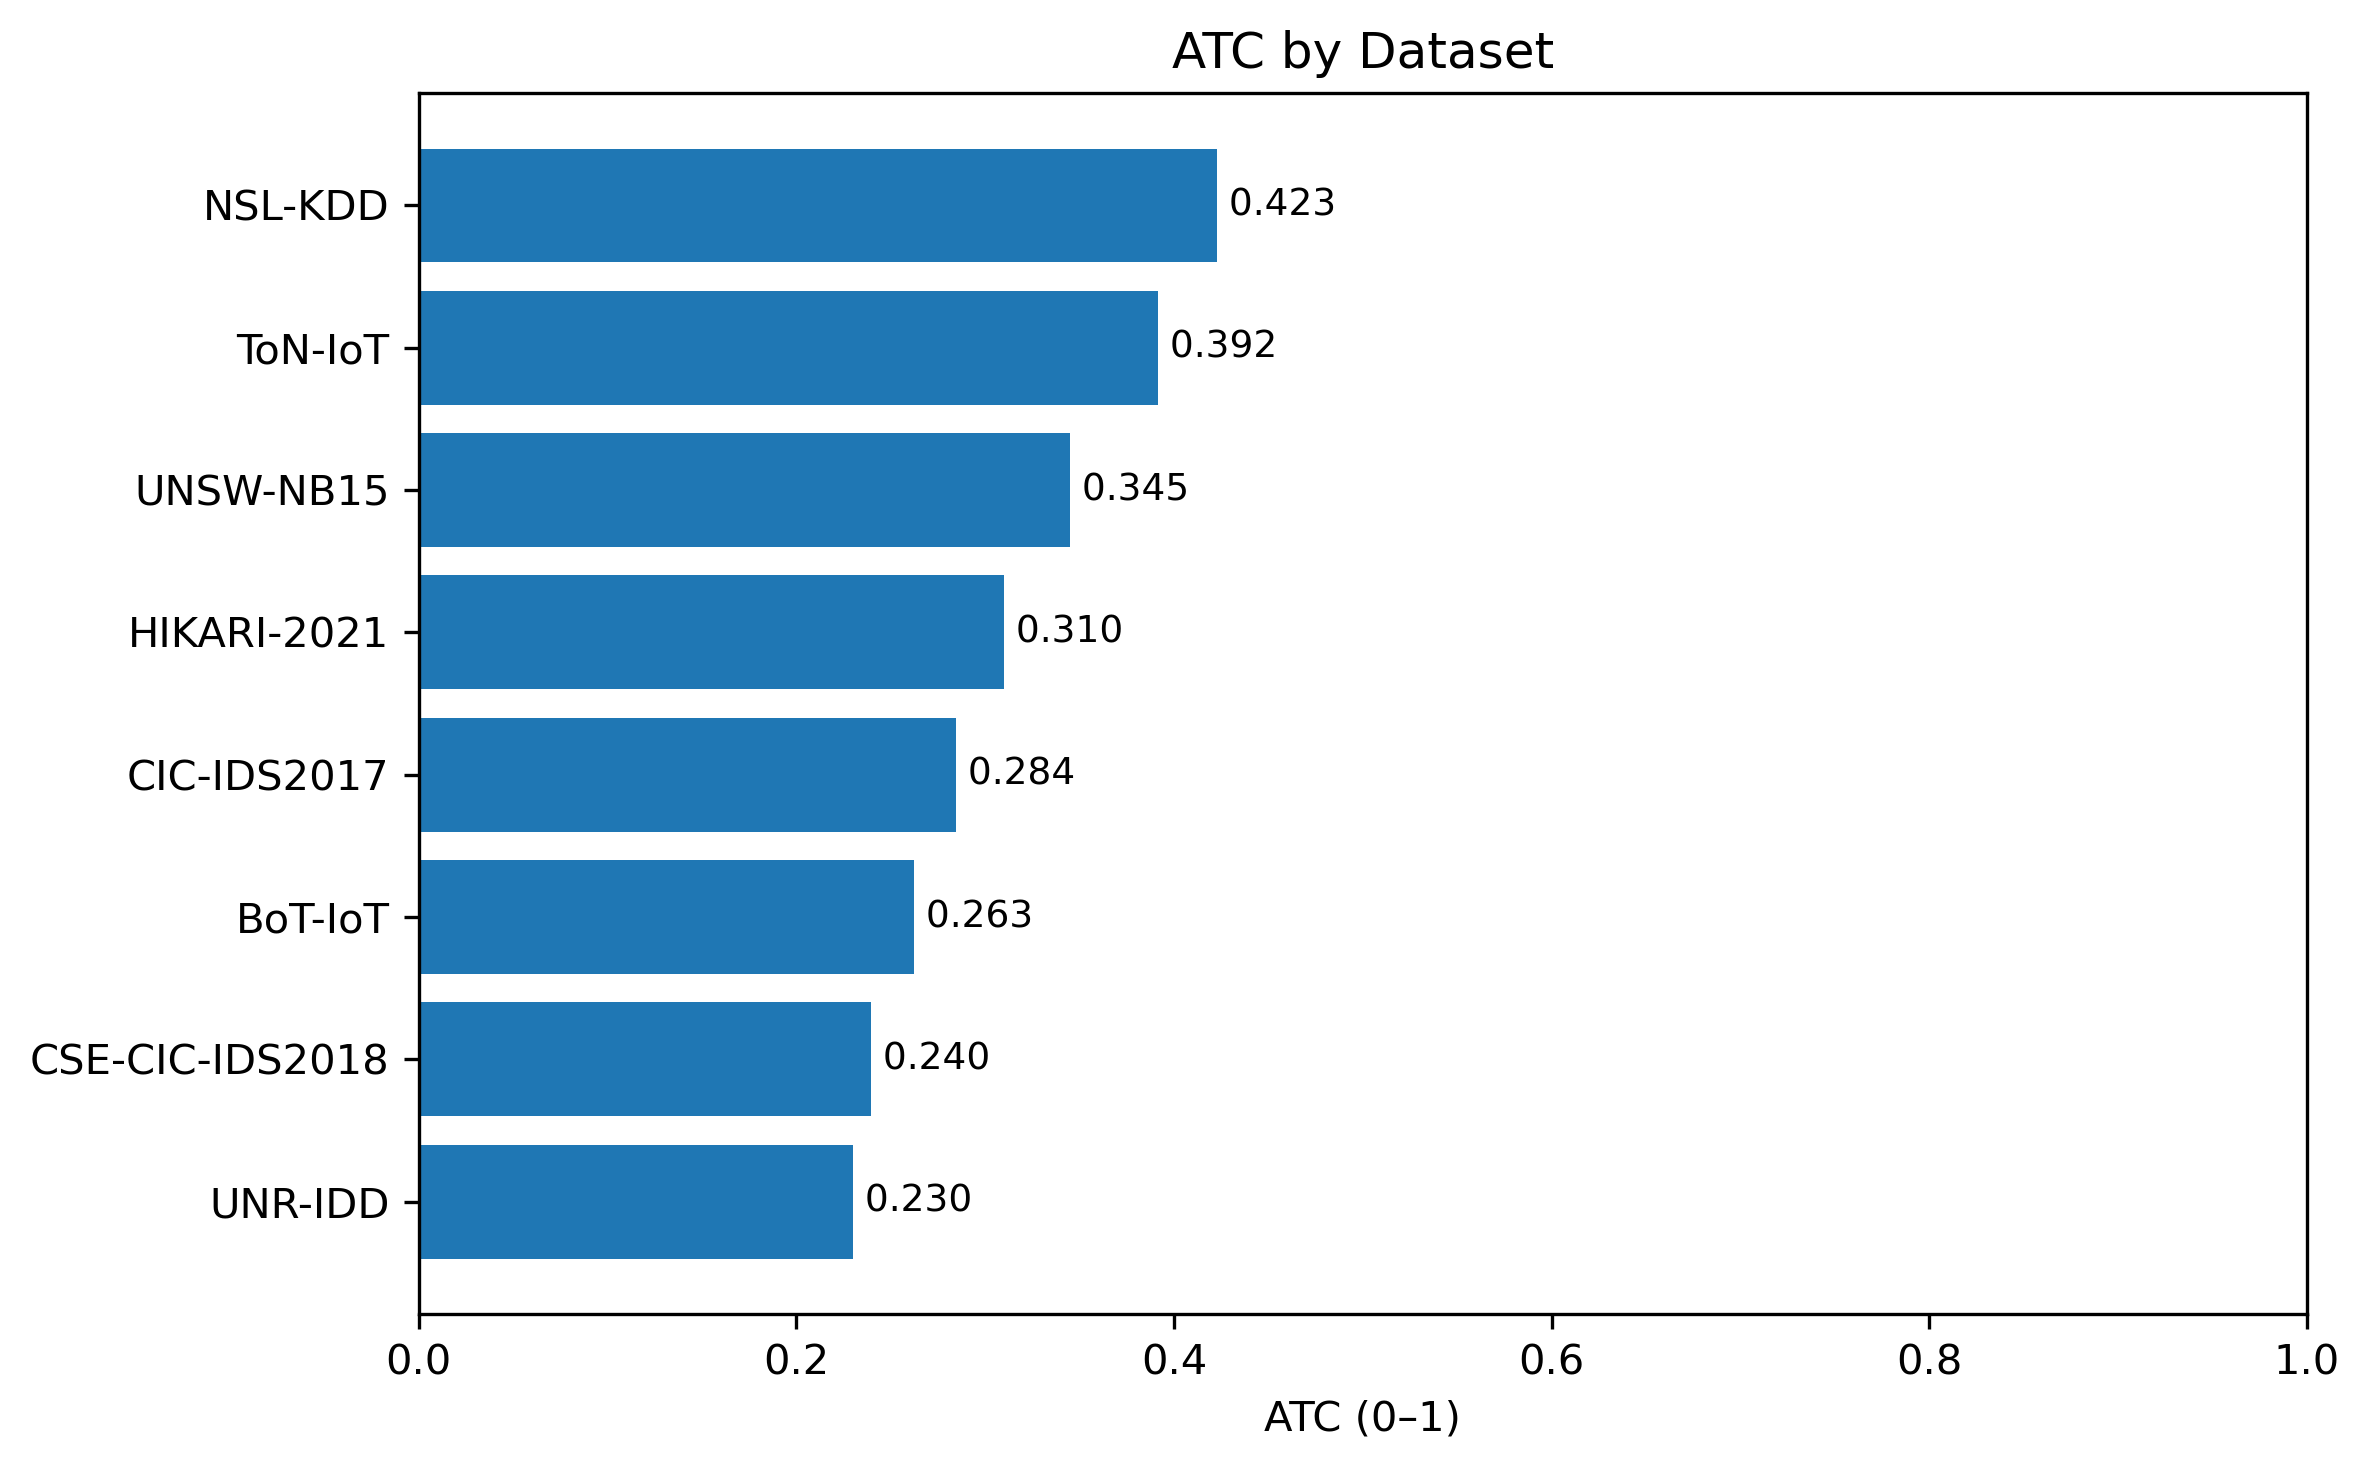

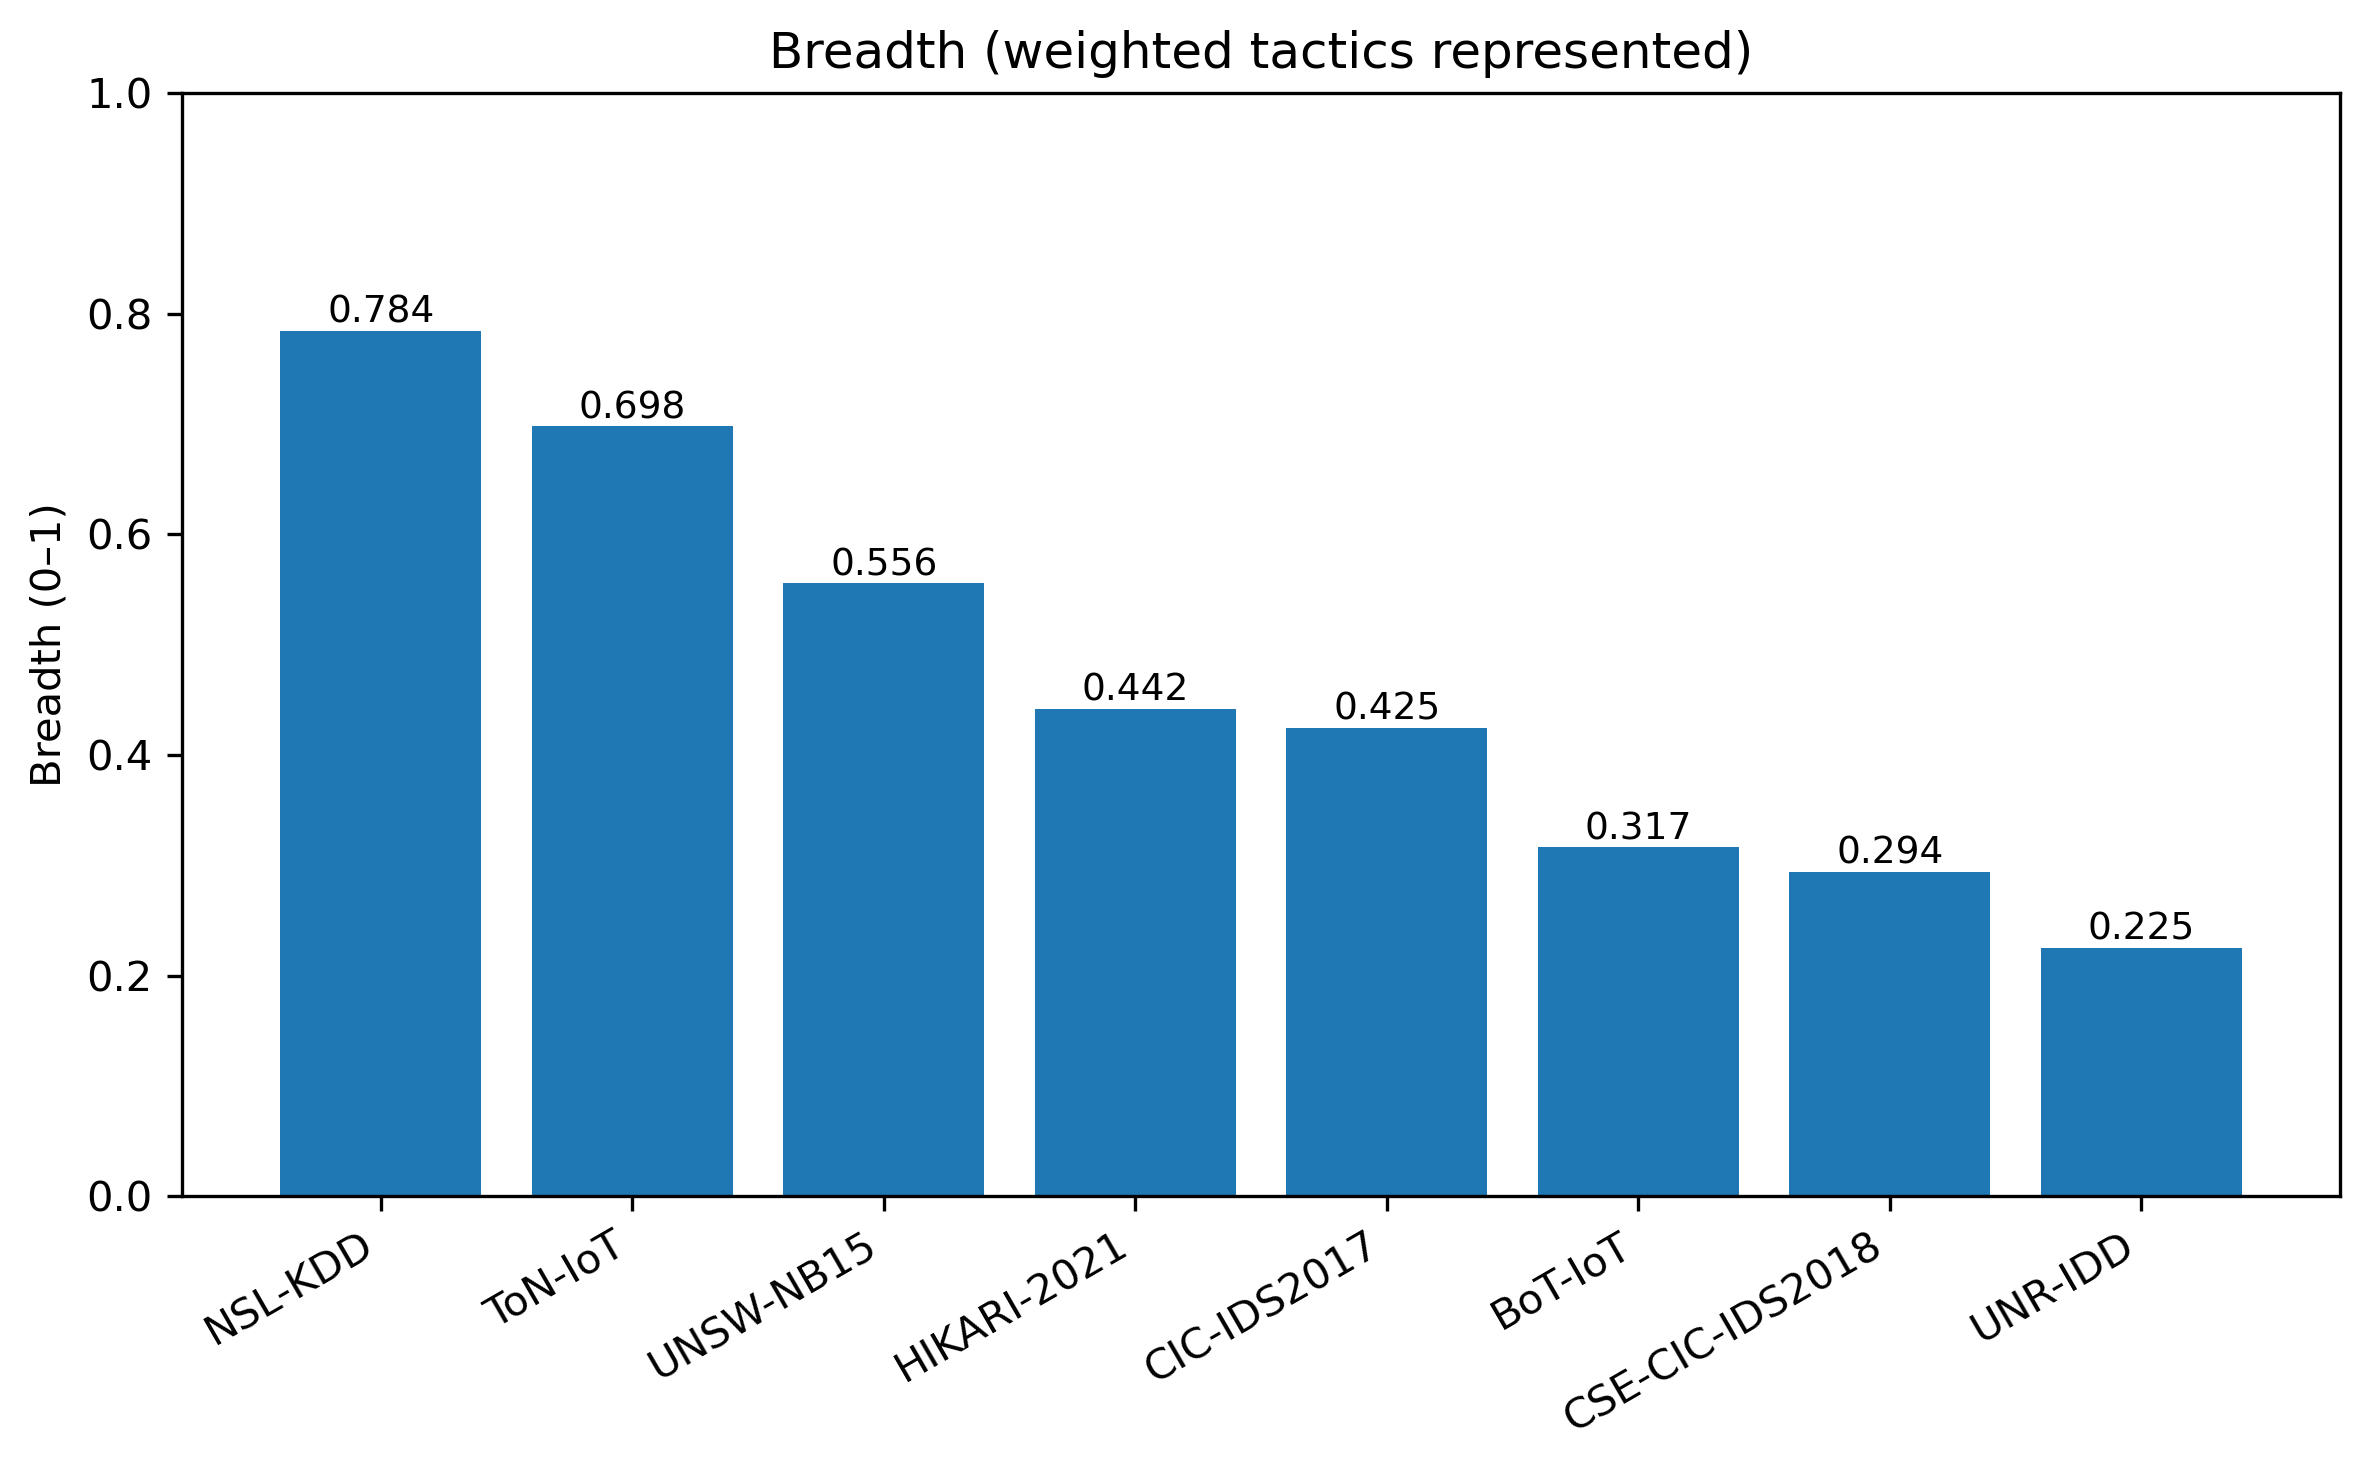

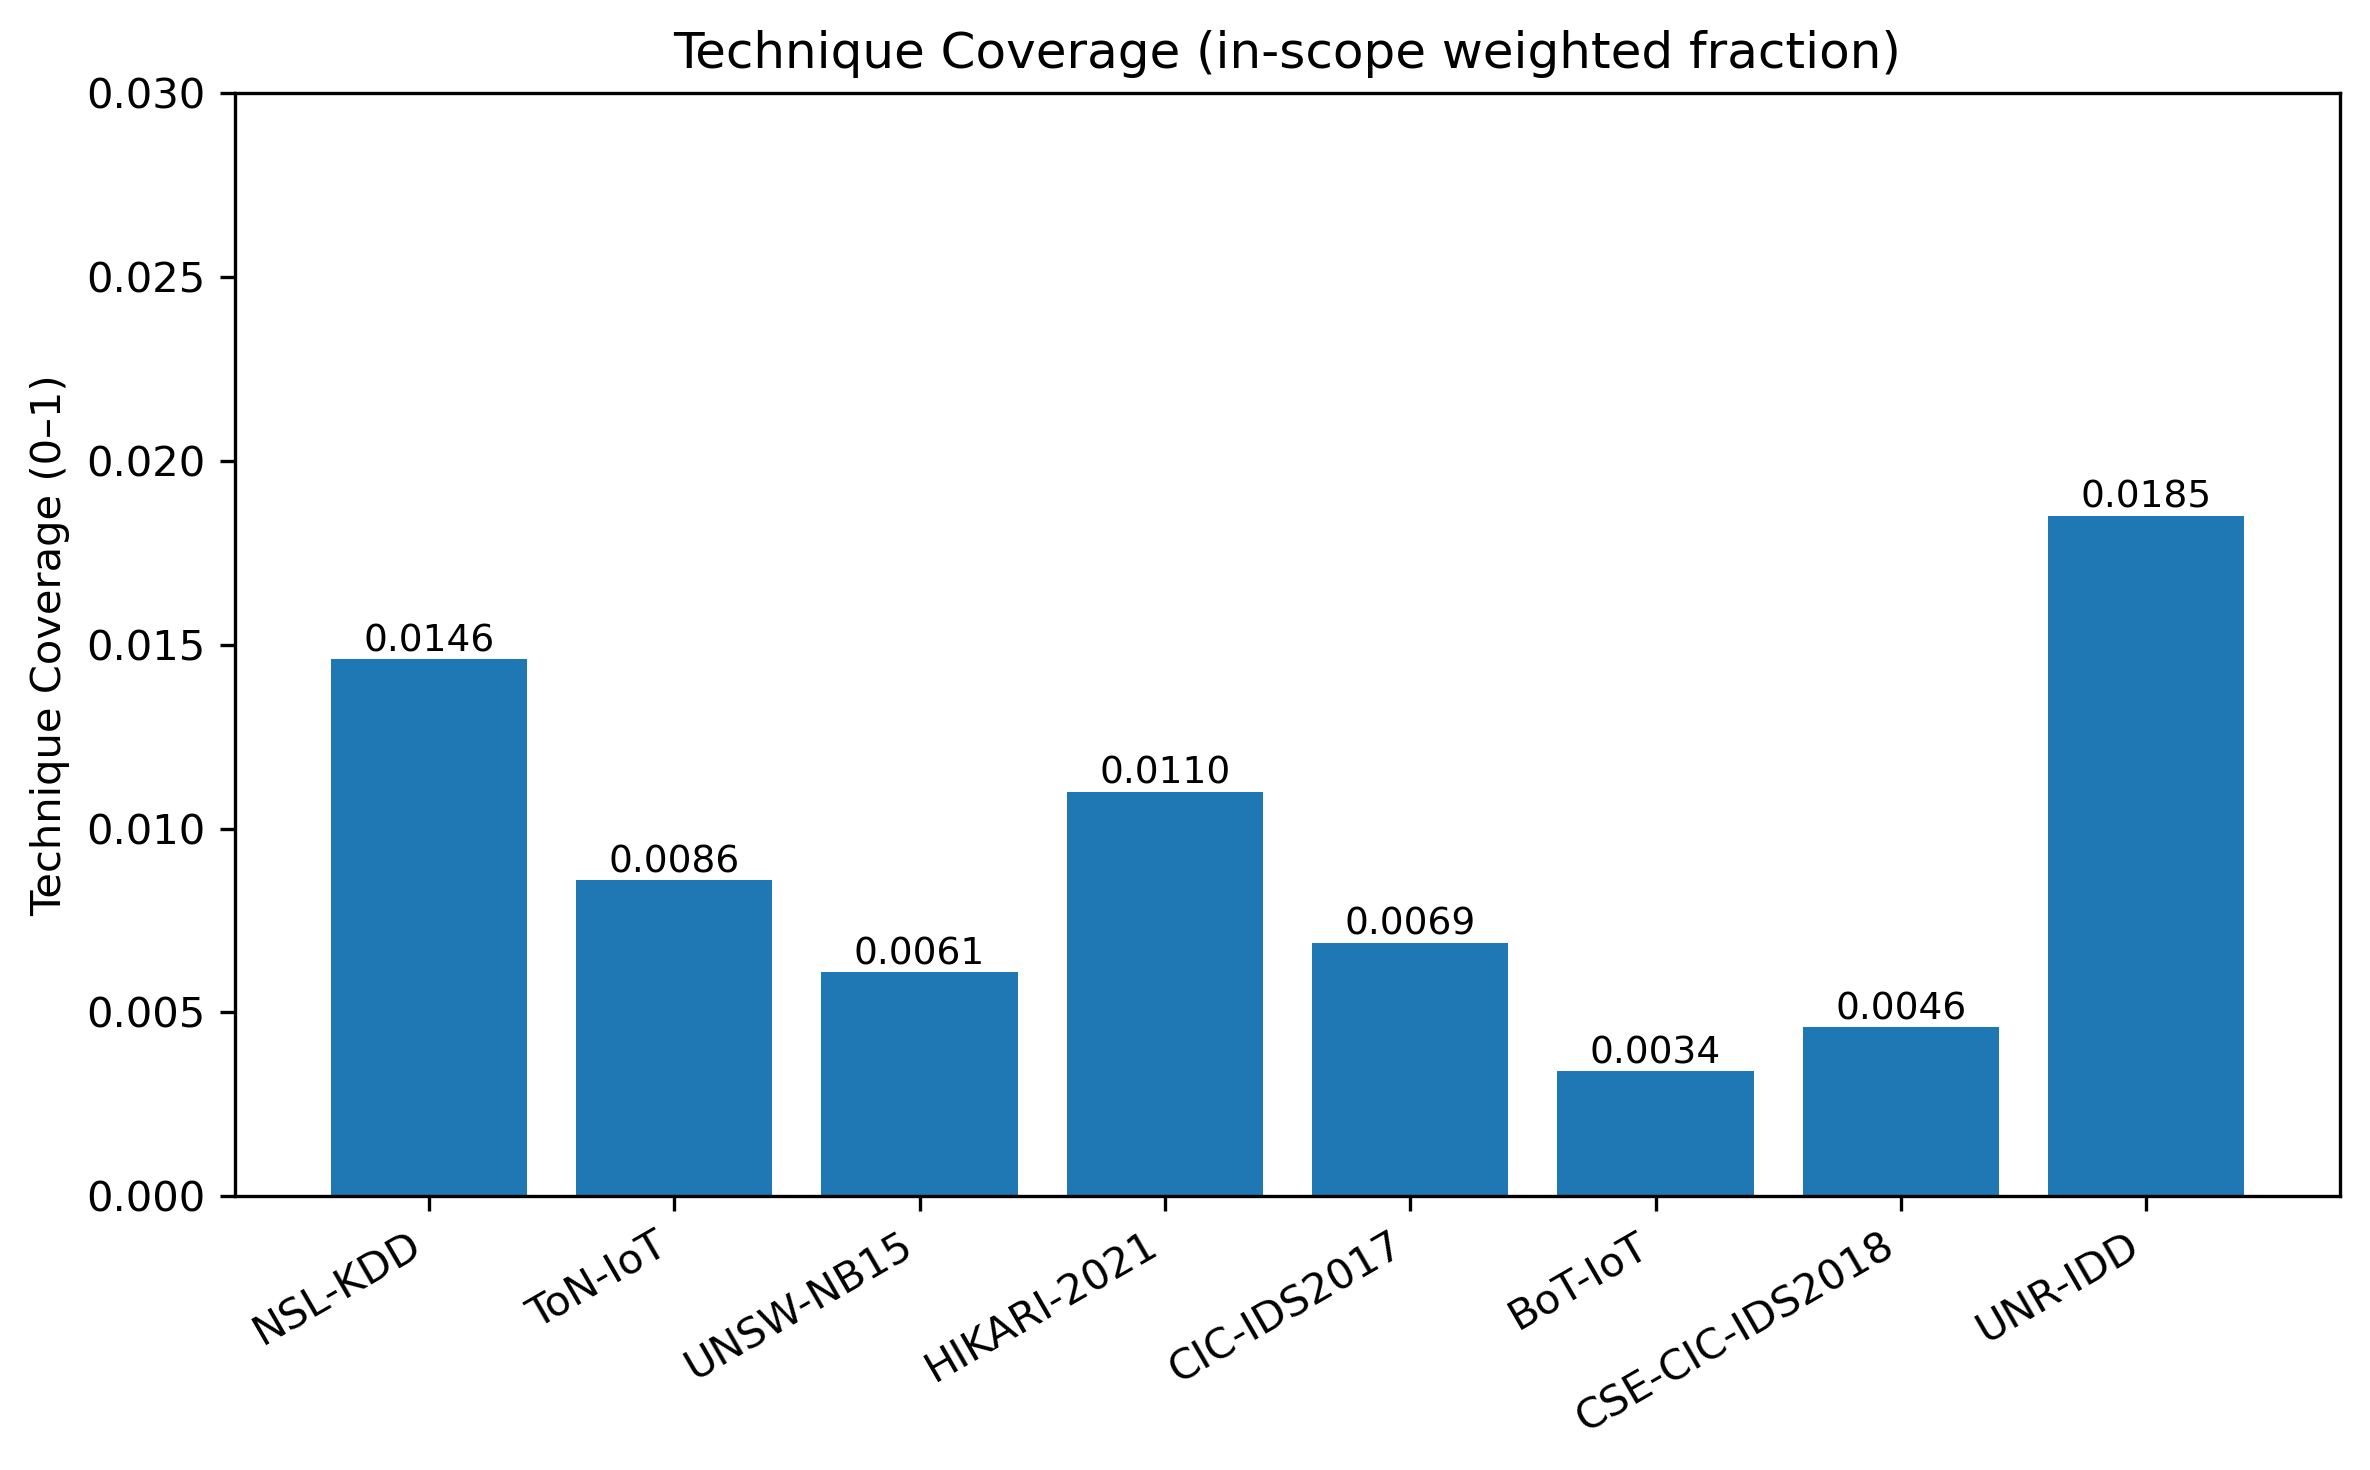

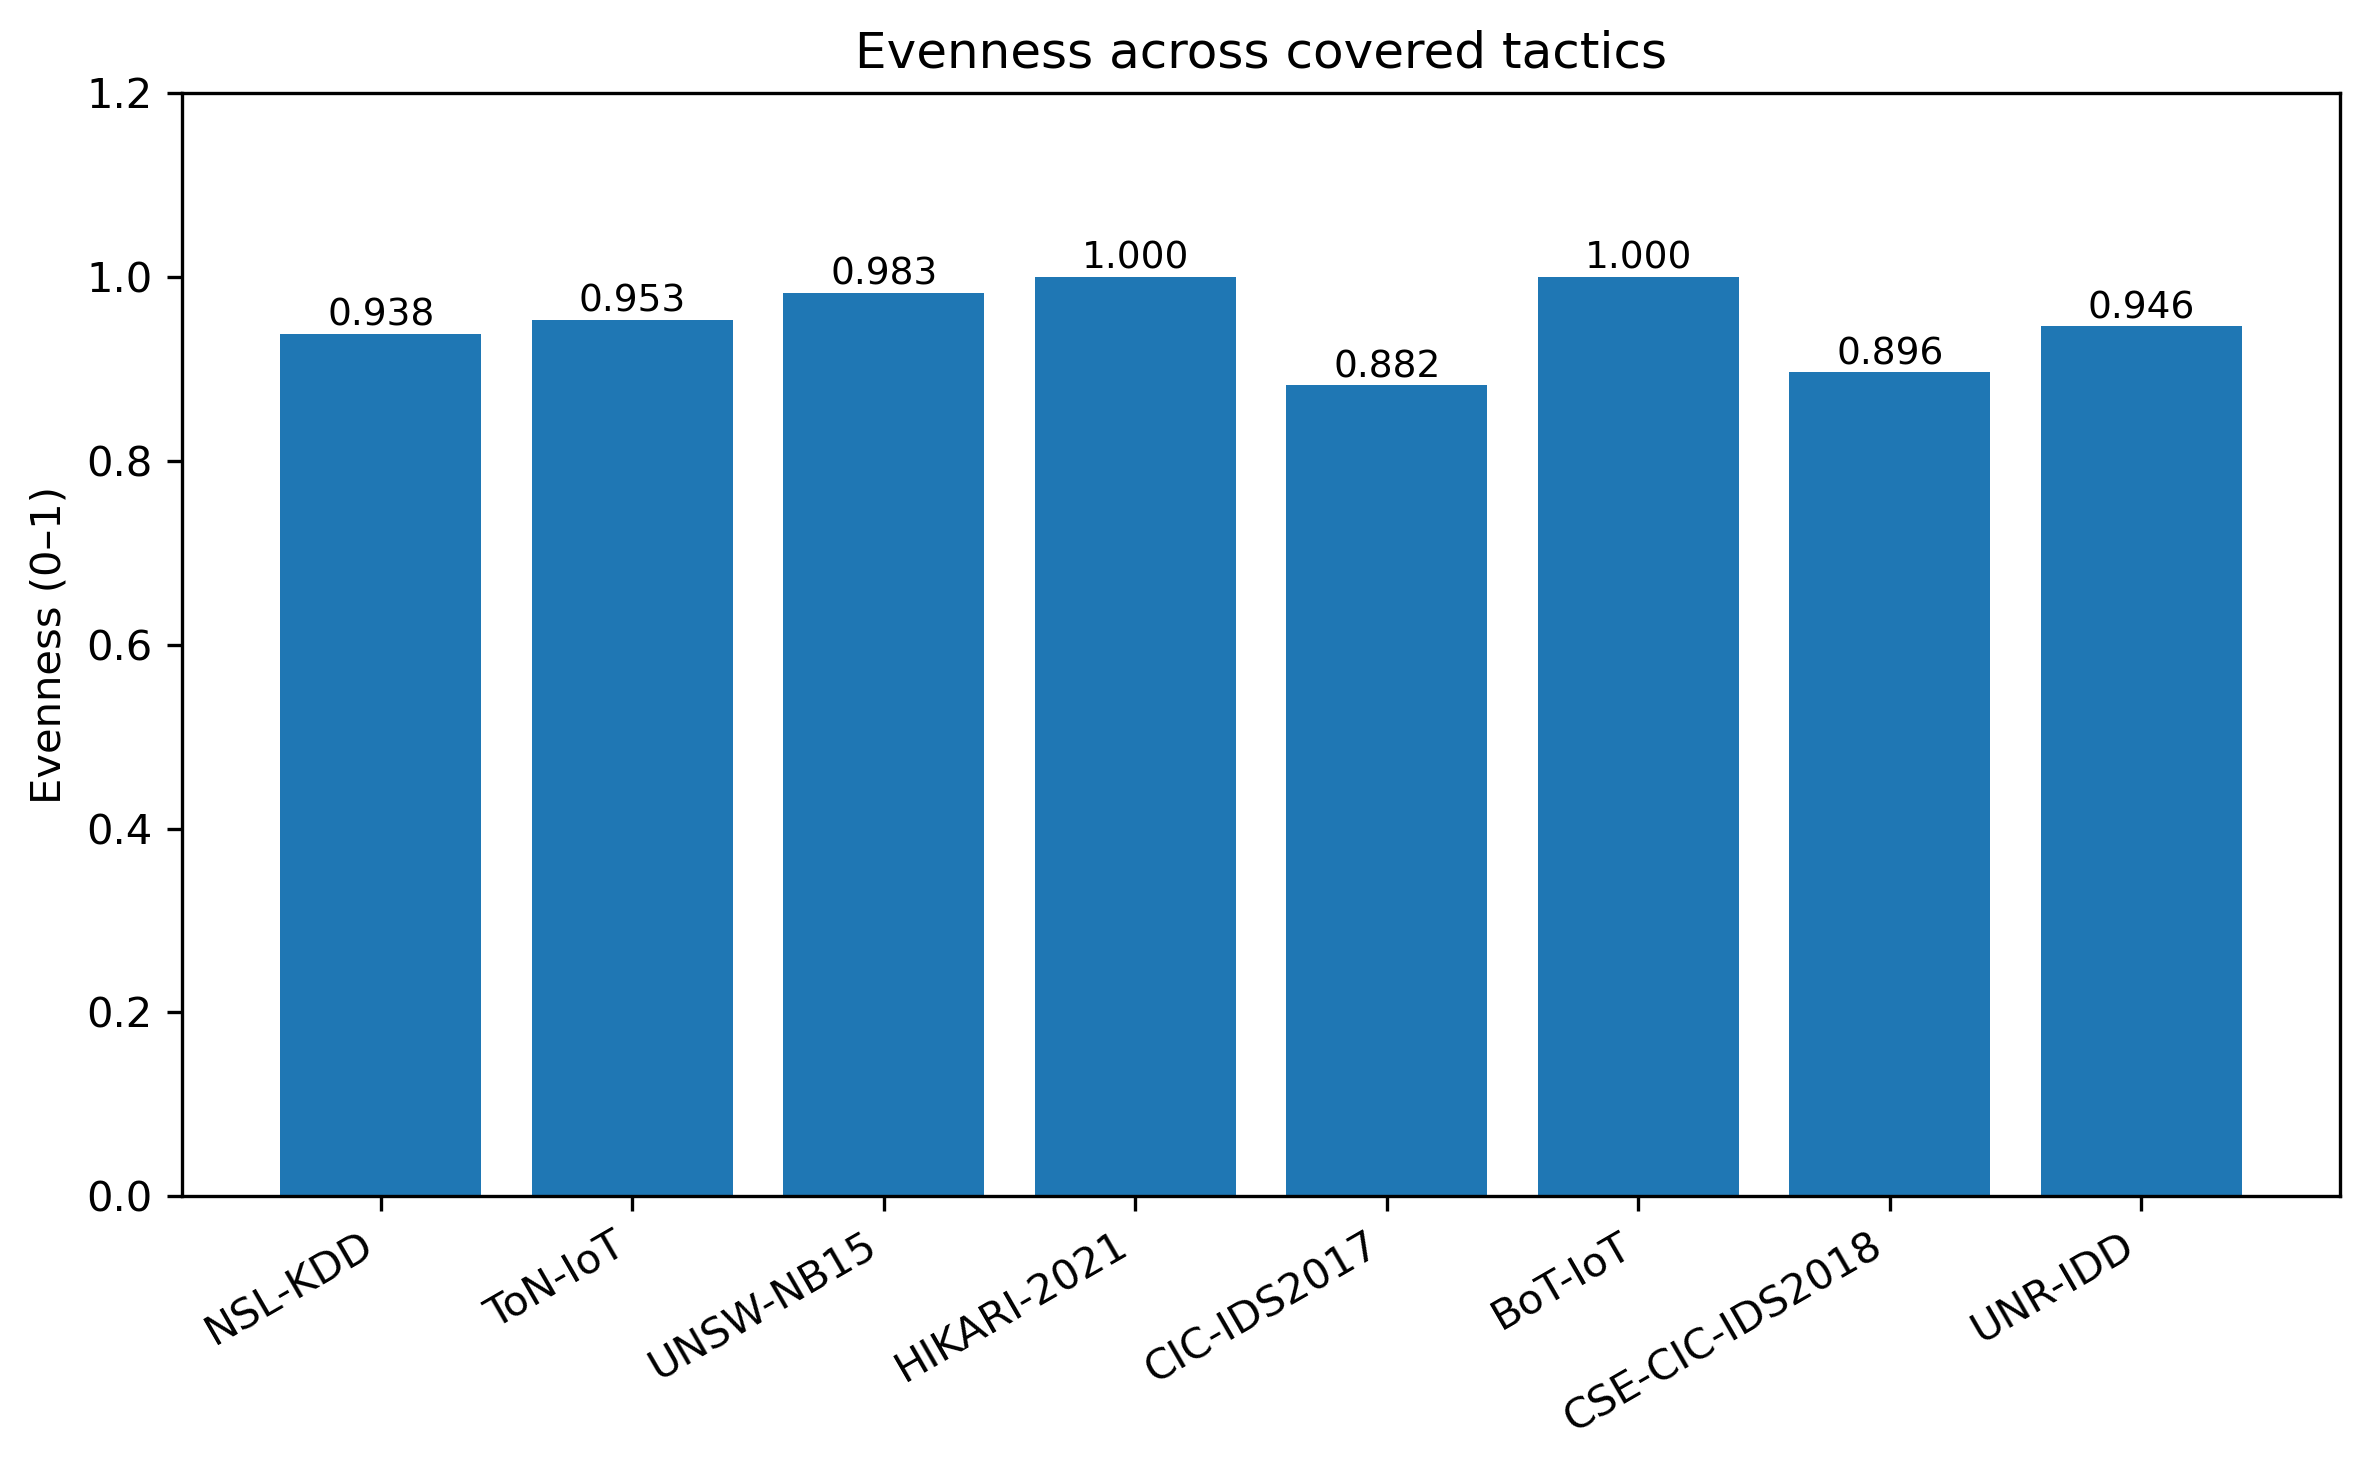

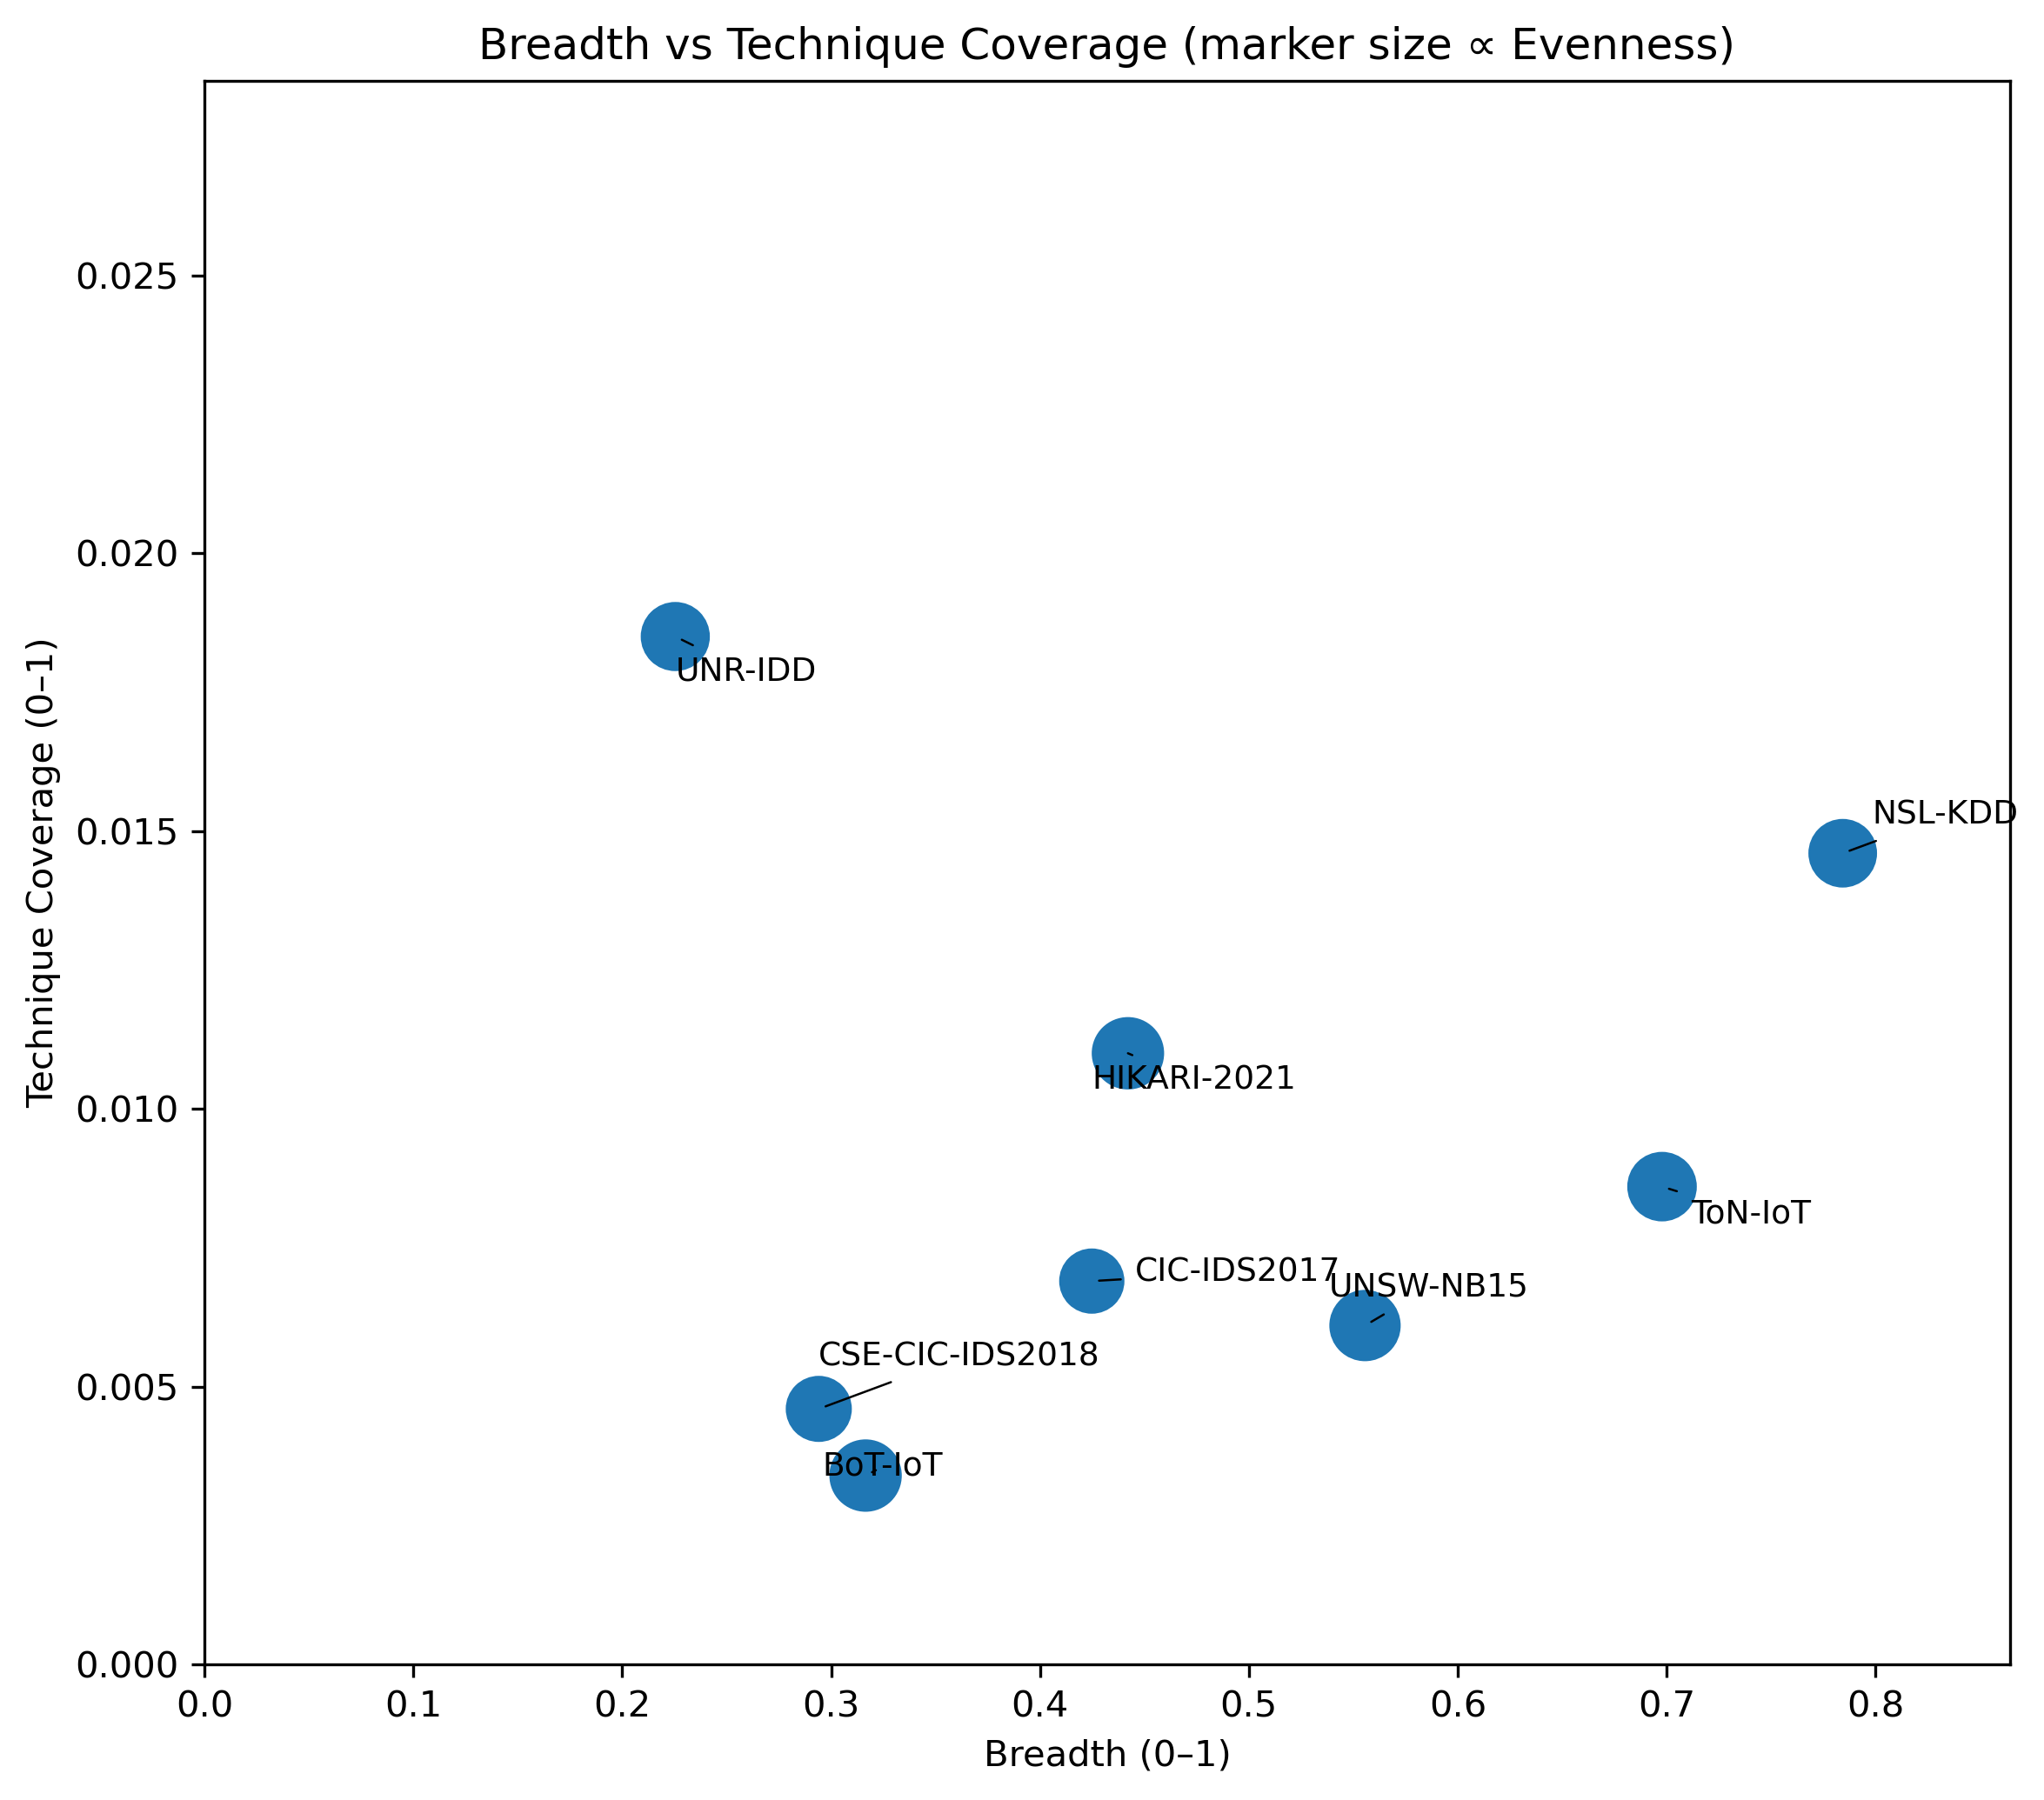

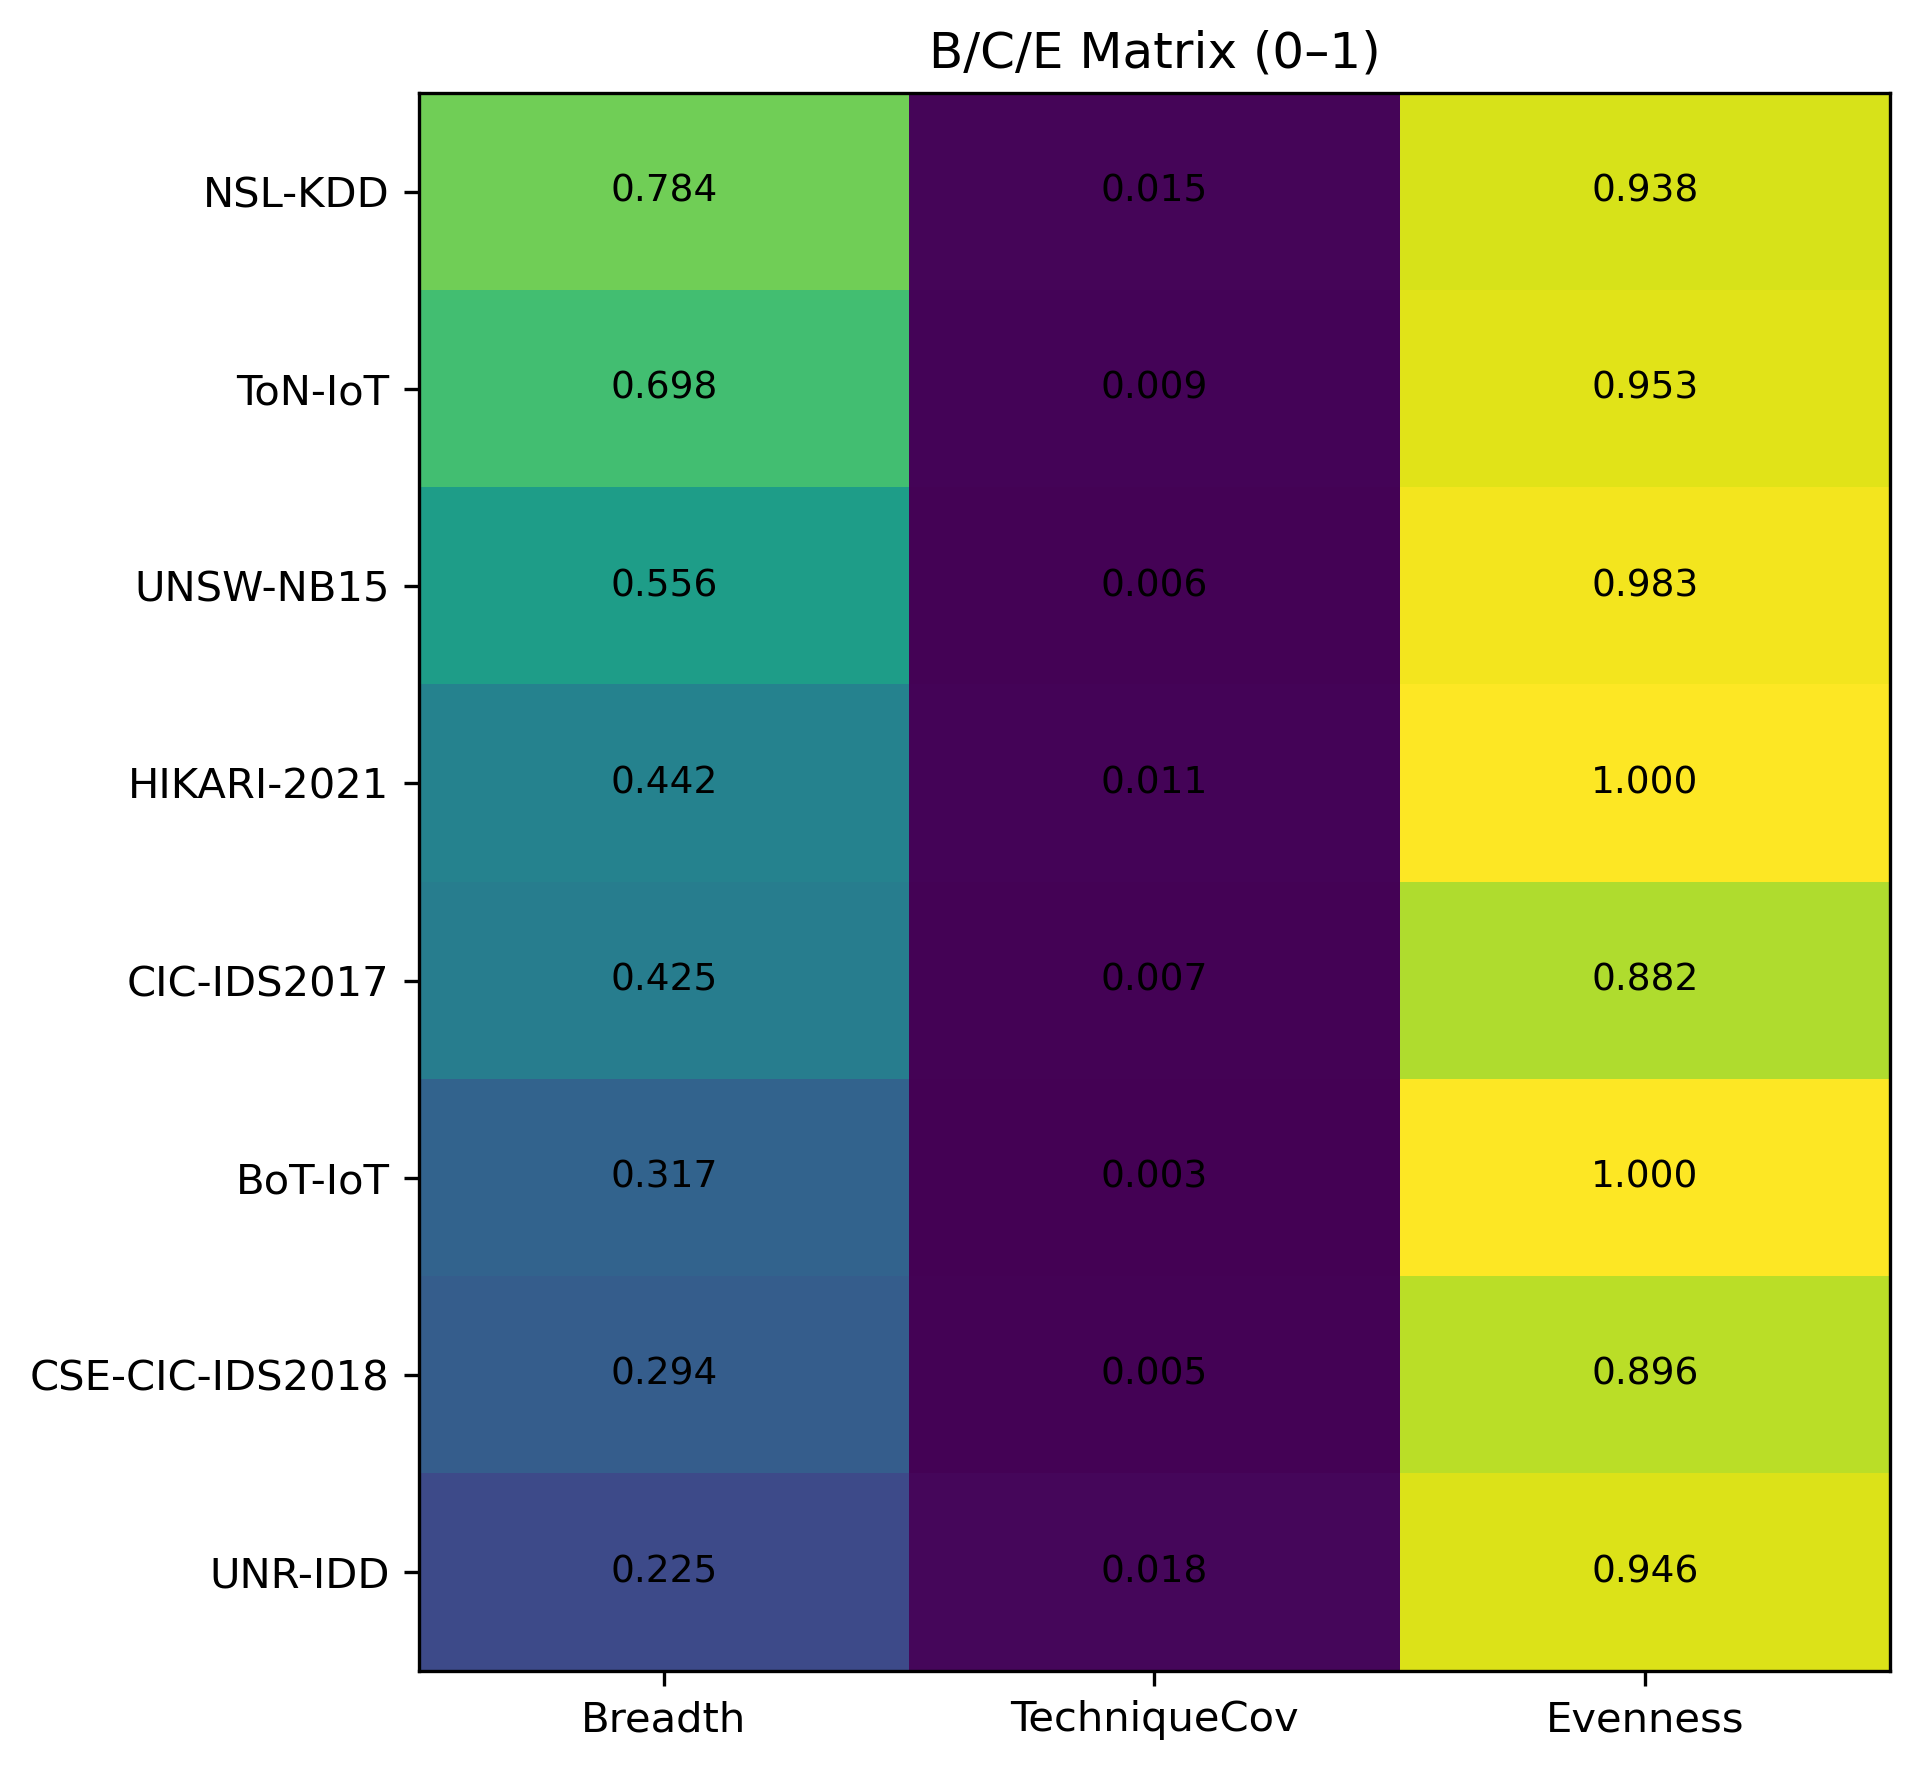

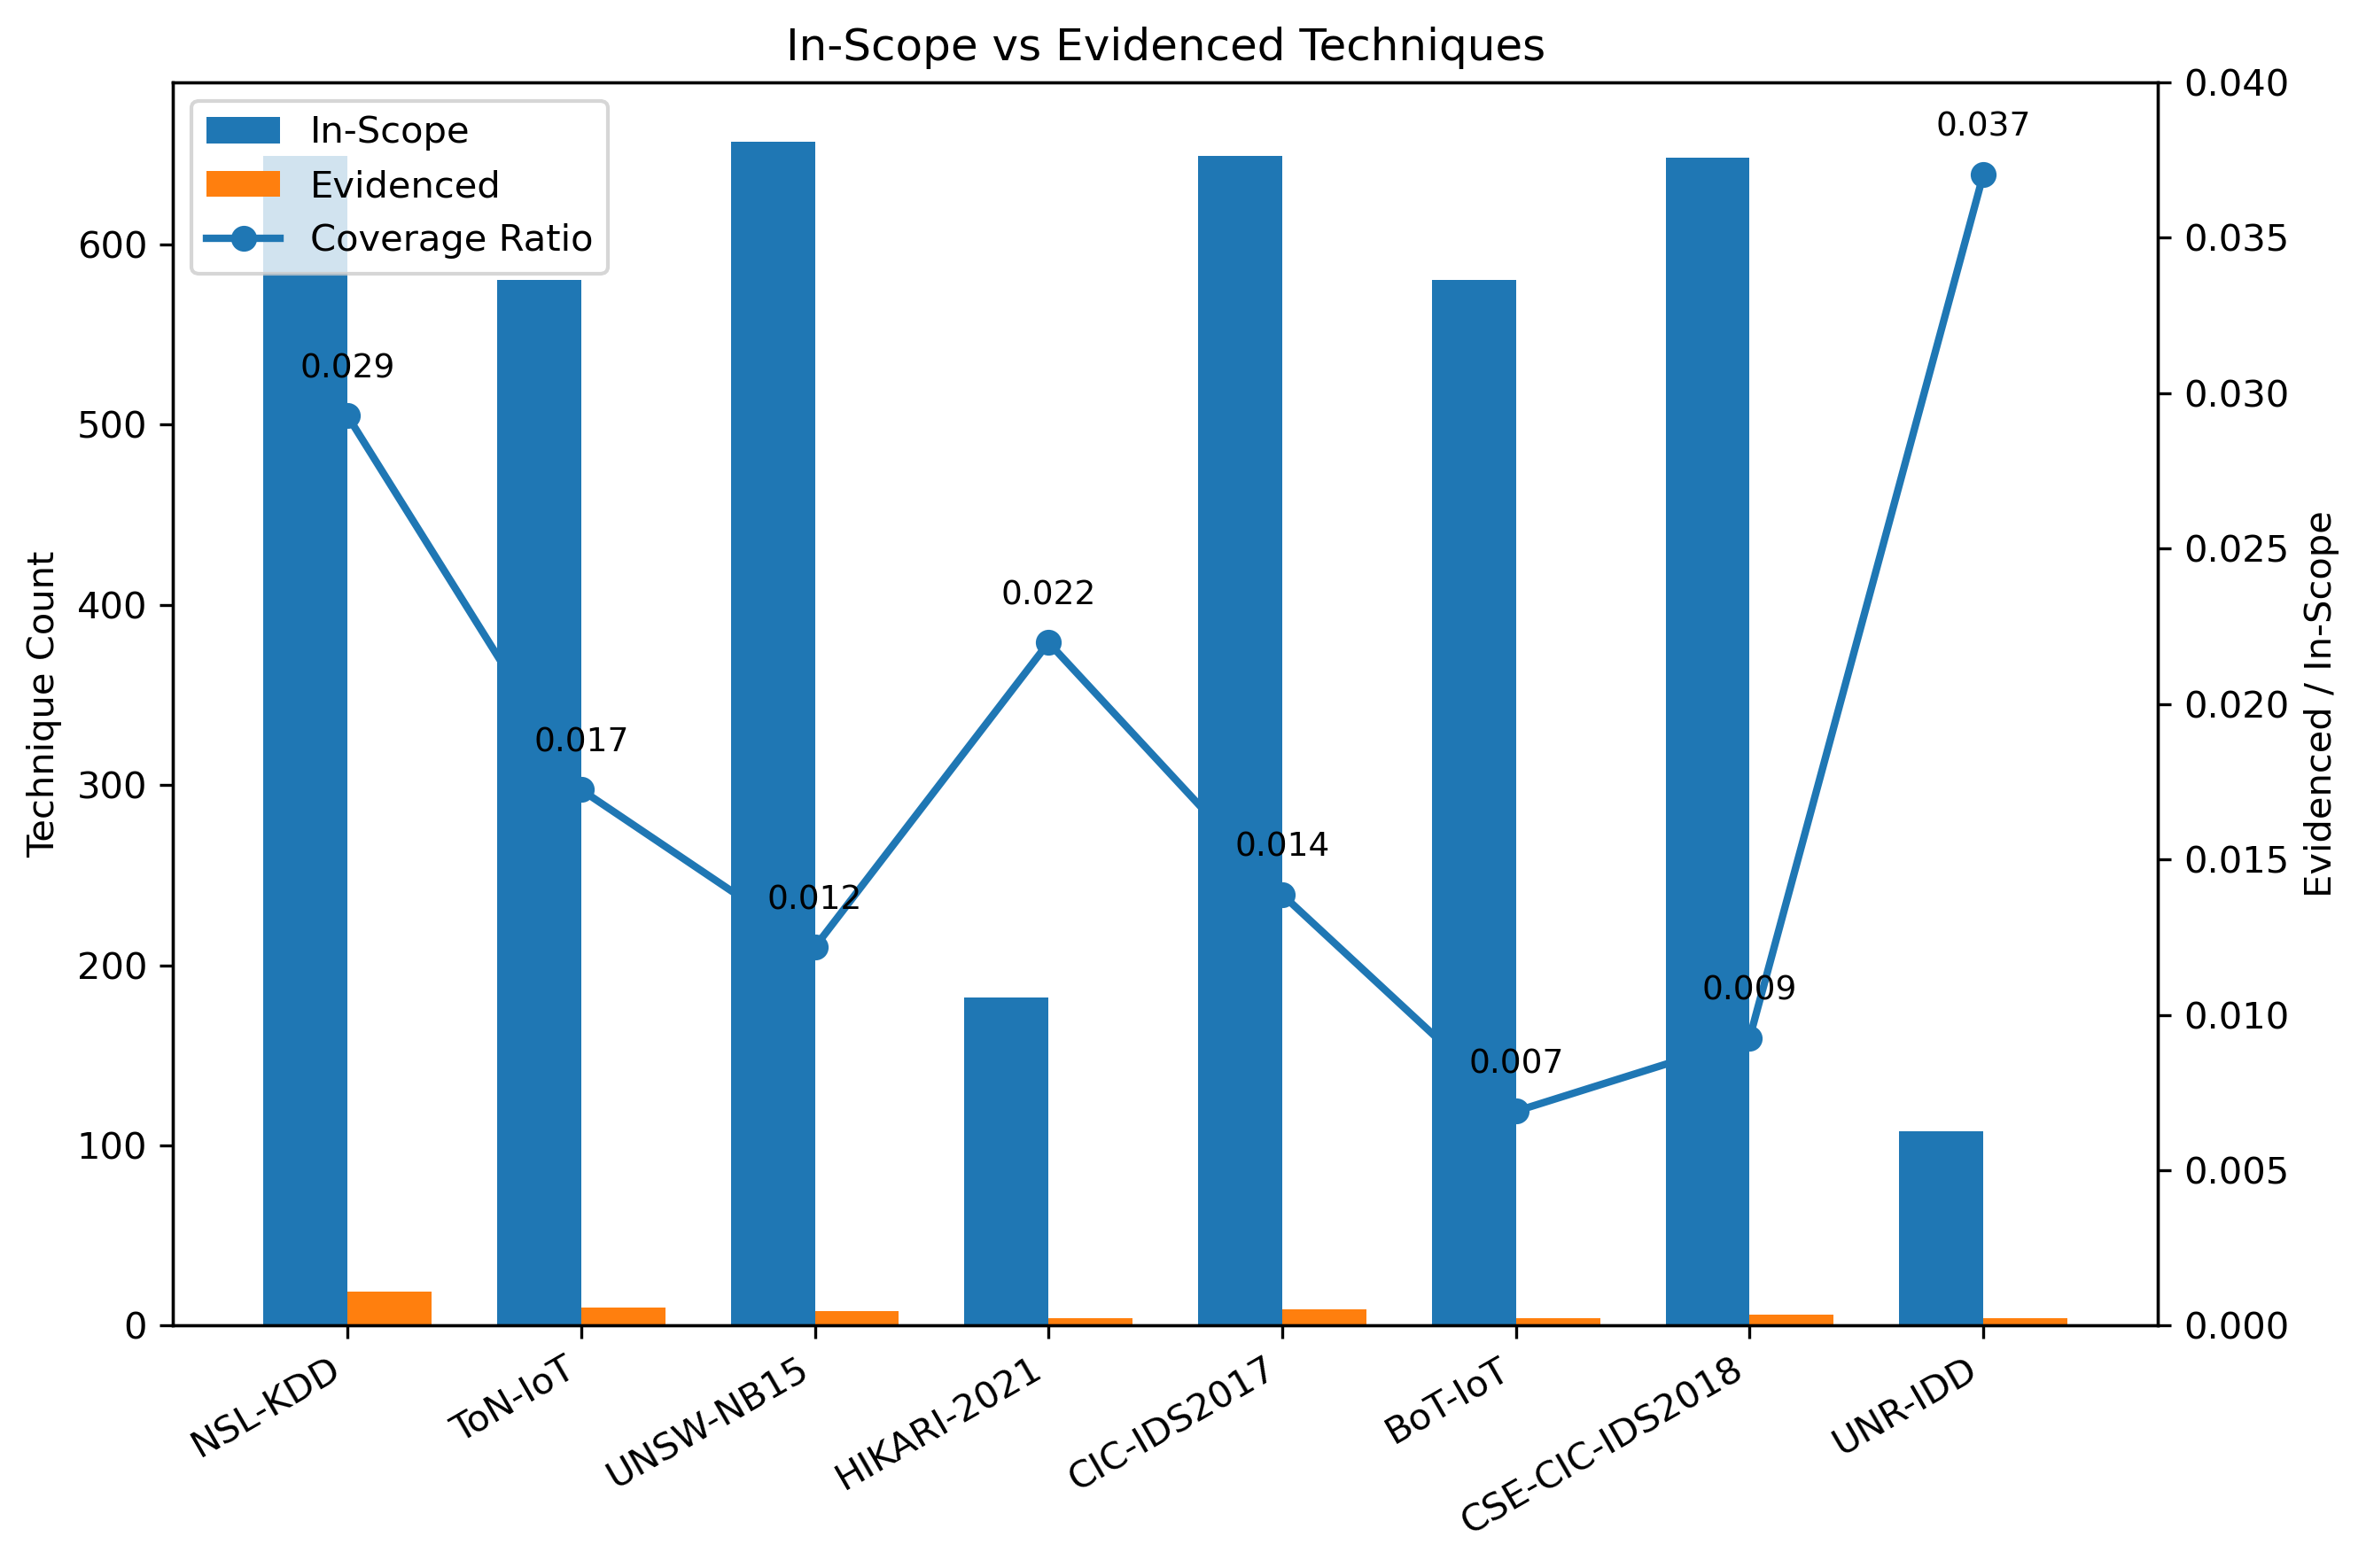

In [9]:
# === ATC Visualization (unit scale: 0..1, publication-ready) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Input data (unit scale)
# -------------------------
summary_df = pd.DataFrame([
    {"dataset":"NSL-KDD","ATC":0.4226,"Breadth":0.7843,"TechniqueCov":0.0146,"Evenness":0.9384,"InScope":649,"Evidenced":19,"CoveredTactics":11},
    {"dataset":"ToN-IoT","ATC":0.3916,"Breadth":0.6978,"TechniqueCov":0.0086,"Evenness":0.9534,"InScope":580,"Evidenced":10,"CoveredTactics":9},
    {"dataset":"UNSW-NB15","ATC":0.3449,"Breadth":0.5556,"TechniqueCov":0.0061,"Evenness":0.9826,"InScope":657,"Evidenced":8,"CoveredTactics":8},
    {"dataset":"HIKARI-2021","ATC":0.3102,"Breadth":0.4421,"TechniqueCov":0.0110,"Evenness":1.0000,"InScope":182,"Evidenced":4,"CoveredTactics":4},
    {"dataset":"CIC-IDS2017","ATC":0.2845,"Breadth":0.4248,"TechniqueCov":0.0069,"Evenness":0.8824,"InScope":649,"Evidenced":9,"CoveredTactics":6},
    {"dataset":"BoT-IoT","ATC":0.2625,"Breadth":0.3165,"TechniqueCov":0.0034,"Evenness":1.0000,"InScope":580,"Evidenced":4,"CoveredTactics":4},
    {"dataset":"CSE-CIC-IDS2018","ATC":0.2397,"Breadth":0.2941,"TechniqueCov":0.0046,"Evenness":0.8962,"InScope":648,"Evidenced":6,"CoveredTactics":4},
    {"dataset":"UNR-IDD","ATC":0.2301,"Breadth":0.2254,"TechniqueCov":0.0185,"Evenness":0.9464,"InScope":108,"Evidenced":4,"CoveredTactics":3},
])

summary_df["CoverageRatio"] = (summary_df["Evidenced"] / summary_df["InScope"]).fillna(0.0)

# Output directory
out_dir = "atc_figs_unit"
os.makedirs(out_dir, exist_ok=True)

# Sort consistently
summary_df = summary_df.sort_values("ATC", ascending=False).reset_index(drop=True)

# -------------------------
# Helper: annotate bars
# -------------------------
def _annotate_bars(ax, orientation="h", fmt="{:.3f}", fontsize=9):
    if orientation == "h":
        for p in ax.patches:
            w = p.get_width()
            ax.text(w, p.get_y()+p.get_height()/2, " " + fmt.format(w),
                    va="center", ha="left", fontsize=fontsize)
    else:
        for p in ax.patches:
            h = p.get_height()
            ax.text(p.get_x()+p.get_width()/2, h, "\n" + fmt.format(h),
                    va="bottom", ha="center", fontsize=fontsize)

# -------------------------
# 1) ATC bar (horizontal)
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.barh(summary_df["dataset"], summary_df["ATC"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("ATC (0–1)")
ax.set_title("ATC by Dataset")
_annotate_bars(ax, "h")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "01_atc_unit.png"))
plt.show()

# -------------------------
# 2) Breadth
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.bar(summary_df["dataset"], summary_df["Breadth"])
ax.set_ylim(0, 1)
ax.set_ylabel("Breadth (0–1)")
ax.set_title("Breadth (weighted tactics represented)")
plt.xticks(rotation=30, ha="right")
_annotate_bars(ax, "v")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "02_breadth_unit.png"))
plt.show()

# -------------------------
# 3) Technique Coverage
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.bar(summary_df["dataset"], summary_df["TechniqueCov"])
ax.set_ylim(0, 0.03)  # zoom for visibility
ax.set_ylabel("Technique Coverage (0–1)")
ax.set_title("Technique Coverage (in-scope weighted fraction)")
plt.xticks(rotation=30, ha="right")
_annotate_bars(ax, "v", fmt="{:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "03_techcov_unit.png"))
plt.show()

# -------------------------
# 4) Evenness
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.bar(summary_df["dataset"], summary_df["Evenness"])
ax.set_ylim(0, 1.2)
ax.set_ylabel("Evenness (0–1)")
ax.set_title("Evenness across covered tactics")
plt.xticks(rotation=30, ha="right")
_annotate_bars(ax, "v")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "04_evenness_unit.png"))
plt.show()

# -------------------------
# 5) Scatter: Breadth vs Technique Coverage (READABLE)
# -------------------------
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

x = summary_df["Breadth"].to_numpy()
y = summary_df["TechniqueCov"].to_numpy()
sizes = 320 * (summary_df["Evenness"]**2) + 40

ax.scatter(x, y, s=sizes)

# Add breathing room
ax.set_xlim(0, min(1.0, x.max() + 0.08))
ax.set_ylim(0, min(0.03, y.max() + 0.01))

offsets = [(8,8),(8,-10),(-10,8),(-10,-10),(12,0),(-12,0),(0,12),(0,-12)]

for i, row in summary_df.iterrows():
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        row["dataset"],
        (row["Breadth"], row["TechniqueCov"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(arrowstyle="-", lw=0.6)
    )

ax.set_xlabel("Breadth (0–1)")
ax.set_ylabel("Technique Coverage (0–1)")
ax.set_title("Breadth vs Technique Coverage (marker size ∝ Evenness)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "05_scatter_unit_readable.png"))
plt.show()

# -------------------------
# 6) B/C/E matrix
# -------------------------
metrics = ["Breadth", "TechniqueCov", "Evenness"]
M = summary_df[metrics].to_numpy()

fig, ax = plt.subplots(figsize=(6.5, 6), dpi=300)
im = ax.imshow(M, aspect="auto", vmin=0, vmax=1)
ax.set_yticks(np.arange(len(summary_df)))
ax.set_yticklabels(summary_df["dataset"])
ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(metrics)
ax.set_title("B/C/E Matrix (0–1)")

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "06_bce_matrix_unit.png"))
plt.show()

# -------------------------
# 7) In-scope vs Evidenced + Ratio
# -------------------------
fig, ax1 = plt.subplots(figsize=(9, 6), dpi=300)
idx = np.arange(len(summary_df))
width = 0.36

ax1.bar(idx - width/2, summary_df["InScope"], width, label="In-Scope")
ax1.bar(idx + width/2, summary_df["Evidenced"], width, label="Evidenced")
ax1.set_ylabel("Technique Count")
ax1.set_xticks(idx)
ax1.set_xticklabels(summary_df["dataset"], rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(idx, summary_df["CoverageRatio"], marker="o", linewidth=2, label="Coverage Ratio")
ax2.set_ylim(0, 0.04)  # zoom ratio
ax2.set_ylabel("Evidenced / In-Scope")

for i, r in enumerate(summary_df["CoverageRatio"]):
    ax2.text(i, r + 0.001, f"{r:.3f}", ha="center", va="bottom", fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("In-Scope vs Evidenced Techniques")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "07_inscope_evidenced_ratio_unit.png"))
plt.show()
